# 0 - Import Libary, Config and Load Data

## 0.1 - Import Library and Config

In [1]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# Konfigurasi path (sinkron dengan notebook bismillah-semtup.ipynb)
BASE_DIR = Path("/kaggle/input/datasets/wildanhasanahfitrah/oil-and-gas-dataset/data_fix")
WC_DIR = BASE_DIR / "working_conditions"
TA_DIR = BASE_DIR / "test_anomaly"
OUTPUT_DIR = Path("/kaggle/working/eda_final")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# Sensor yang dianalisis
SENSOR_COLS = ["S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8"]

# Reproduktibilitas
SEED = 42
np.random.seed(SEED)

# Skema warna kelompok (konsisten di seluruh notebook)
COLORS = {
    "WC1 Normal": "steelblue",
    "Semua WC Normal": "royalblue",
    "TA Normal": "seagreen",
    "TA Anomali": "crimson",
}

# Deskripsi dan satuan sensor (sumber: Mazzuto et al. 2025, Data in Brief)
SENSOR_UNITS = {
    "S1": "bar",     # Inlet water pressure
    "S2": "m³/h",    # Inlet water flow rate
    "S3": "bar",     # Pressure inside the ejector
    "S4": "bar",     # Pressure inside the diffuser
    "S5": "bar",     # Pressure inside the vertical tank
    "S6": "mm",      # Water level inside the tank
    "S7": "m³/h",    # Inlet air flow rate
    "S8": "m³/h",    # Outlet air flow rate
}

print("Konfigurasi:")
print(f"  WC_DIR    : {WC_DIR}")
print(f"  TA_DIR    : {TA_DIR}")
print(f"  OUTPUT_DIR: {OUTPUT_DIR}")
print(f"  Sensor    : {SENSOR_COLS}")
print(f"  Seed      : {SEED}")
print(f"  Satuan    : {SENSOR_UNITS}")

Konfigurasi:
  WC_DIR    : /kaggle/input/datasets/wildanhasanahfitrah/oil-and-gas-dataset/data_fix/working_conditions
  TA_DIR    : /kaggle/input/datasets/wildanhasanahfitrah/oil-and-gas-dataset/data_fix/test_anomaly
  OUTPUT_DIR: /kaggle/working/eda_final
  Sensor    : ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8']
  Seed      : 42
  Satuan    : {'S1': 'bar', 'S2': 'm³/h', 'S3': 'bar', 'S4': 'bar', 'S5': 'bar', 'S6': 'mm', 'S7': 'm³/h', 'S8': 'm³/h'}


## 0.2 - Load Data

In [2]:
def natural_key(name: str):
    """Sort natural: WC1, WC2, ..., WC10 (bukan WC1, WC10, WC2)."""
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r"(\d+)", str(name))]


def load_xlsx(filepath: Path, default_label: int = 0) -> pd.DataFrame:
    """Load 1 file XLSX menjadi DataFrame dengan cleaning kolom standar."""
    df = pd.read_excel(filepath, engine="openpyxl")
    df.columns = [str(c).strip() for c in df.columns]

    # Hapus kolom index artefak
    unnamed_cols = [c for c in df.columns if c.lower().startswith("unnamed:")]
    if unnamed_cols:
        df = df.drop(columns=unnamed_cols)

    # Standarisasi nama kolom label
    if "label" not in df.columns:
        for cand in ["anomaly", "fault", "is_anomaly"]:
            if cand in df.columns:
                df = df.rename(columns={cand: "label"})
                break
        else:
            df["label"] = default_label

    df["label"] = df["label"].astype(int)
    return df


# ============================================================
# Load 46 file Working Condition (kondisi operasi normal)
# ============================================================
wc_files = sorted(WC_DIR.glob("working_condition*.xlsx"), key=lambda p: natural_key(p.name))
print(f"Jumlah file WC ditemukan  : {len(wc_files)}")

wc_dfs = {}
for p in wc_files:
    name = p.stem  # working_condition1, working_condition2, dst
    df = load_xlsx(p, default_label=0)
    df["source_file"] = p.name
    wc_dfs[name] = df

print(f"Total baris WC            : {sum(len(df) for df in wc_dfs.values()):,}")

# ============================================================
# Load 7 file Test Anomaly severity 'severe'
# ============================================================
ta_all_files = sorted(TA_DIR.rglob("anomaly*.xlsx"), key=lambda p: natural_key(p.name))
ta_severe_files = [p for p in ta_all_files if "severe" in str(p).lower()]
print(f"\nJumlah file TA severe     : {len(ta_severe_files)}")

ta_dfs = {}
for p in ta_severe_files:
    # Extract valve dari nama file: anomalyVM1_severe.xlsx -> VM1
    fname_l = p.stem.lower()
    valve = "unknown"
    for vm in ["vm1", "vm2", "vm3", "vm4", "vm5", "vm6", "vm7"]:
        if vm in fname_l:
            valve = vm.upper()
            break
    name = f"{valve}_severe"
    df = load_xlsx(p)
    df["source_file"] = p.name
    df["valve"] = valve
    ta_dfs[name] = df

print(f"Total baris TA severe     : {sum(len(df) for df in ta_dfs.values()):,}")
print(f"File TA yang dimuat       : {list(ta_dfs.keys())}")

# ============================================================
# Pembentukan 4 kelompok data untuk analisis
# ============================================================

# Kelompok 1: WC1 Normal (referensi setpoint-identik dengan TA)
df_wc1 = wc_dfs["working_condition1"][SENSOR_COLS].copy()

# Kelompok 2: Semua WC Normal (46 file digabung, envelope operasional lengkap)
df_wc_all = pd.concat(
    [df[SENSOR_COLS] for df in wc_dfs.values()],
    ignore_index=True,
)

# Kelompok 3 & 4: TA dipisah berdasarkan label
df_ta_all = pd.concat([df for df in ta_dfs.values()], ignore_index=True)
df_ta_normal = df_ta_all[df_ta_all["label"] == 0][SENSOR_COLS].copy().reset_index(drop=True)
df_ta_anomali = df_ta_all[df_ta_all["label"] == 1][SENSOR_COLS].copy().reset_index(drop=True)

# Ringkasan 4 kelompok
print("\n" + "=" * 60)
print("Ringkasan 4 kelompok data:")
print("=" * 60)
print(f"  1. WC1 Normal      : {len(df_wc1):>7,} baris  (1 file, setpoint 5.5/300/1.3)")
print(f"  2. Semua WC Normal : {len(df_wc_all):>7,} baris  (46 file, semua setpoint)")
print(f"  3. TA Normal       : {len(df_ta_normal):>7,} baris  (segmen label=0 dari 7 file severe)")
print(f"  4. TA Anomali      : {len(df_ta_anomali):>7,} baris  (segmen label=1 dari 7 file severe)")

Jumlah file WC ditemukan  : 46
Total baris WC            : 112,195

Jumlah file TA severe     : 7
Total baris TA severe     : 18,840
File TA yang dimuat       : ['VM1_severe', 'VM2_severe', 'VM3_severe', 'VM4_severe', 'VM5_severe', 'VM6_severe', 'VM7_severe']

Ringkasan 4 kelompok data:
  1. WC1 Normal      :   2,019 baris  (1 file, setpoint 5.5/300/1.3)
  2. Semua WC Normal : 112,195 baris  (46 file, semua setpoint)
  3. TA Normal       :  11,732 baris  (segmen label=0 dari 7 file severe)
  4. TA Anomali      :   7,108 baris  (segmen label=1 dari 7 file severe)


# 1 - Statistik Distribusi

## 1.1 - Tabel Statistik

In [3]:
from scipy import stats as scipy_stats


def compute_statistics(df: pd.DataFrame, kelompok_name: str) -> pd.DataFrame:
    """
    Hitung 10 statistik deskriptif per sensor untuk satu kelompok data.
    
    Kolom output (11 total termasuk identitas):
        Sensor, Kelompok, N, Mean, Std, Min, Q1, Median, Q3, Max, IQR, Skewness, Kurtosis
    """
    rows = []
    for col in SENSOR_COLS:
        series = df[col].dropna()
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        rows.append({
            "Sensor":   col,
            "Kelompok": kelompok_name,
            "N":        len(series),
            "Mean":     series.mean(),
            "Std":      series.std(),
            "Min":      series.min(),
            "Q1":       q1,
            "Median":   series.quantile(0.50),
            "Q3":       q3,
            "Max":      series.max(),
            "IQR":      q3 - q1,
            "Skewness": scipy_stats.skew(series, bias=False),
            "Kurtosis": scipy_stats.kurtosis(series, bias=False, fisher=True),
        })
    return pd.DataFrame(rows)


# ============================================================
# Hitung statistik untuk 4 kelompok
# ============================================================
stats_wc1        = compute_statistics(df_wc1,        "WC1 Normal")
stats_wc_all     = compute_statistics(df_wc_all,     "Semua WC Normal")
stats_ta_normal  = compute_statistics(df_ta_normal,  "TA Normal")
stats_ta_anomali = compute_statistics(df_ta_anomali, "TA Anomali")

# ============================================================
# Gabung menjadi long format, urutan per sensor (Opsi a)
# ============================================================
# Urutan kelompok dalam tiap grup sensor
kelompok_order = ["WC1 Normal", "Semua WC Normal", "TA Normal", "TA Anomali"]

stats_all = pd.concat(
    [stats_wc1, stats_wc_all, stats_ta_normal, stats_ta_anomali],
    ignore_index=True,
)

# Sort: per sensor dulu (S1..S8), lalu per kelompok sesuai kelompok_order
stats_all["_sensor_order"] = stats_all["Sensor"].map({s: i for i, s in enumerate(SENSOR_COLS)})
stats_all["_kelompok_order"] = stats_all["Kelompok"].map({k: i for i, k in enumerate(kelompok_order)})
stats_all = (
    stats_all
    .sort_values(["_sensor_order", "_kelompok_order"])
    .drop(columns=["_sensor_order", "_kelompok_order"])
    .reset_index(drop=True)
)

# ============================================================
# Cetak & simpan
# ============================================================
print("Tabel Statistik Distribusi — Long Format (per sensor)")
print("=" * 100)

# Cetak dengan format desimal 4 angka (5 untuk sensor skala kecil seperti S3)
with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", 200,
    "display.float_format", lambda v: f"{v:.2f}",
):
    print(stats_all.to_string(index=False))

# Simpan ke CSV
output_path = OUTPUT_DIR / "01_stats_distribusi_long.csv"
stats_all.to_csv(output_path, index=False)
print(f"\nDisimpan: {output_path}")

Tabel Statistik Distribusi — Long Format (per sensor)
Sensor        Kelompok      N   Mean    Std    Min     Q1  Median     Q3    Max    IQR  Skewness  Kurtosis
    S1      WC1 Normal   2019   5.49   0.73   0.99   5.47    5.51   5.55   6.17   0.08     -4.89     26.45
    S1 Semua WC Normal 112195   4.99   1.27   0.99   4.26    5.48   6.14   6.18   1.88     -1.16      0.94
    S1       TA Normal  11732   4.31   1.97   1.01   1.44    5.48   5.54   6.14   4.10     -0.91     -1.10
    S1      TA Anomali   7108   4.42   1.89   1.01   5.12    5.48   5.52   5.58   0.40     -1.20     -0.53
    S2      WC1 Normal   2019   9.81   1.53   0.02   9.91    9.96  10.00  10.65   0.08     -5.92     34.71
    S2 Semua WC Normal 112195   9.13   2.07   0.01   8.69    9.96  10.63  10.74   1.94     -2.46      7.36
    S2       TA Normal  11732   7.74   3.65   0.49   3.13    9.94  10.00  11.24   6.87     -0.97     -0.98
    S2      TA Anomali   7108   7.75   3.95   0.49   9.62    9.94   9.98  10.80   0.36    

## 1.2 - Boxplot Distribusi Sensor

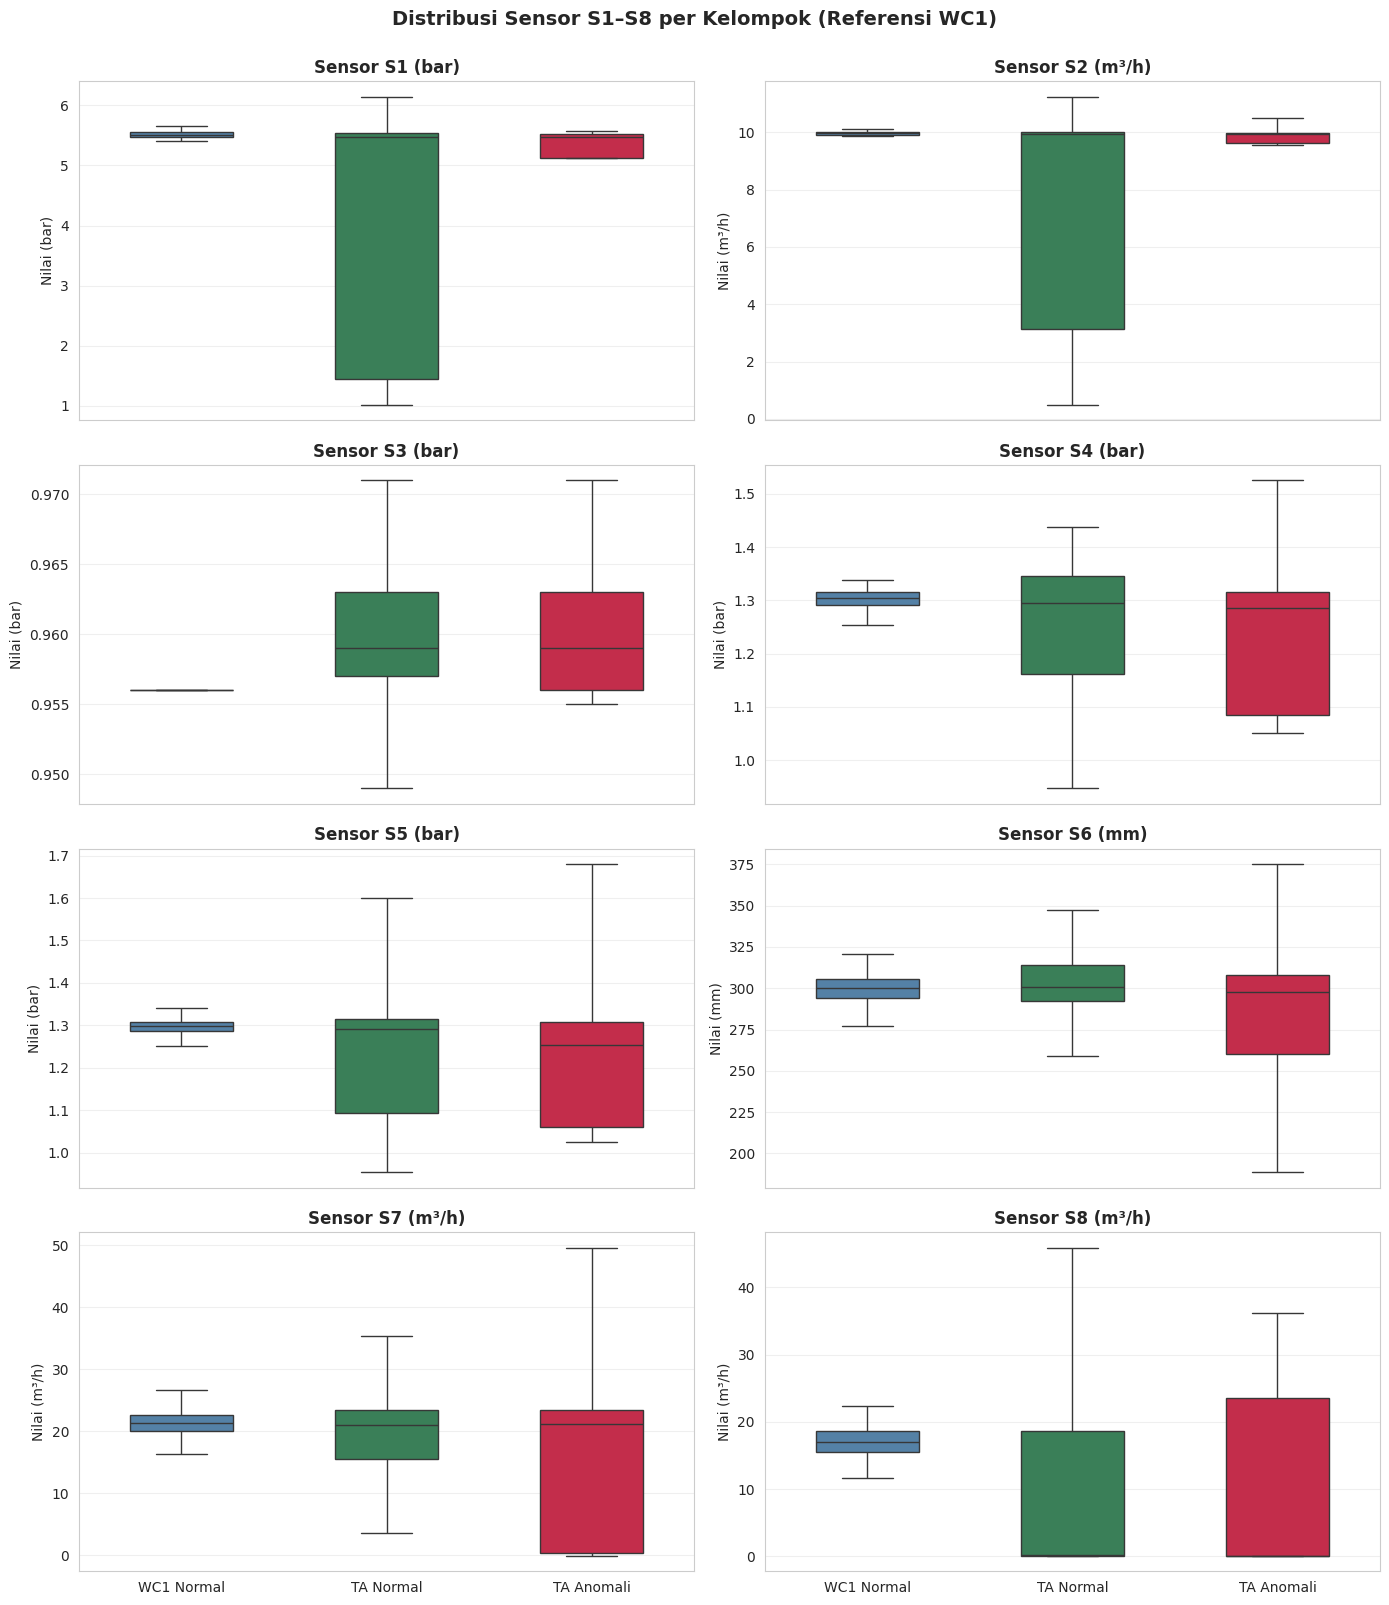

Disimpan: /kaggle/working/eda_final/02_boxplot_sensors_wc1.png


In [4]:
def plot_boxplot_sensors(data_dict: dict, colors: dict, title: str, output_path: Path):
    """
    Plot boxplot 8 sensor (grid 4x2) untuk membandingkan distribusi antar kelompok.
    
    - Share-x on (kategori kelompok sama di semua subplot)
    - Share-y off (skala sensor bervariasi drastis)
    - Outlier disembunyikan (showfliers=False)
    - Kotak = IQR (Q1-Q3), garis tengah = median, whisker = Tukey fence
    """
    # Reshape data ke long format untuk seaborn
    records = []
    for kelompok, df in data_dict.items():
        for sensor in SENSOR_COLS:
            for val in df[sensor].dropna():
                records.append({"Sensor": sensor, "Kelompok": kelompok, "Nilai": val})
    df_long = pd.DataFrame(records)
    
    # Setup grid 4x2 dengan share-x
    fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex=True, sharey=False)
    axes = axes.flatten()
    
    kelompok_order = list(data_dict.keys())
    palette = {k: colors[k] for k in kelompok_order}
    
    for i, sensor in enumerate(SENSOR_COLS):
        ax = axes[i]
        subset = df_long[df_long["Sensor"] == sensor]
        
        # Ambil satuan sensor sebelum dipakai di title dan ylabel
        unit = SENSOR_UNITS.get(sensor, "")
        
        sns.boxplot(
            data=subset,
            x="Kelompok", y="Nilai",
            order=kelompok_order,
            palette=palette,
            showfliers=False,
            width=0.5,
            ax=ax,
        )
        
        ax.set_title(f"Sensor {sensor} ({unit})", fontsize=12, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel(f"Nilai ({unit})" if unit else "Nilai", fontsize=10)
        ax.grid(alpha=0.3, axis="y")
        
        # Label X hanya di baris paling bawah (baris 4, subplot 6 dan 7)
        if i >= 6:
            ax.tick_params(axis="x", labelrotation=0, labelsize=10)
        else:
            ax.tick_params(axis="x", labelbottom=False)
    
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.00)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Disimpan: {output_path}")


# ============================================================
# Data dictionary untuk 3 kelompok (apple-to-apple perbandingan)
# ============================================================
data_3groups = {
    "WC1 Normal":  df_wc1,
    "TA Normal":   df_ta_normal,
    "TA Anomali":  df_ta_anomali,
}

plot_boxplot_sensors(
    data_dict=data_3groups,
    colors=COLORS,
    title="Distribusi Sensor S1–S8 per Kelompok (Referensi WC1)",
    output_path=OUTPUT_DIR / "02_boxplot_sensors_wc1.png",
)

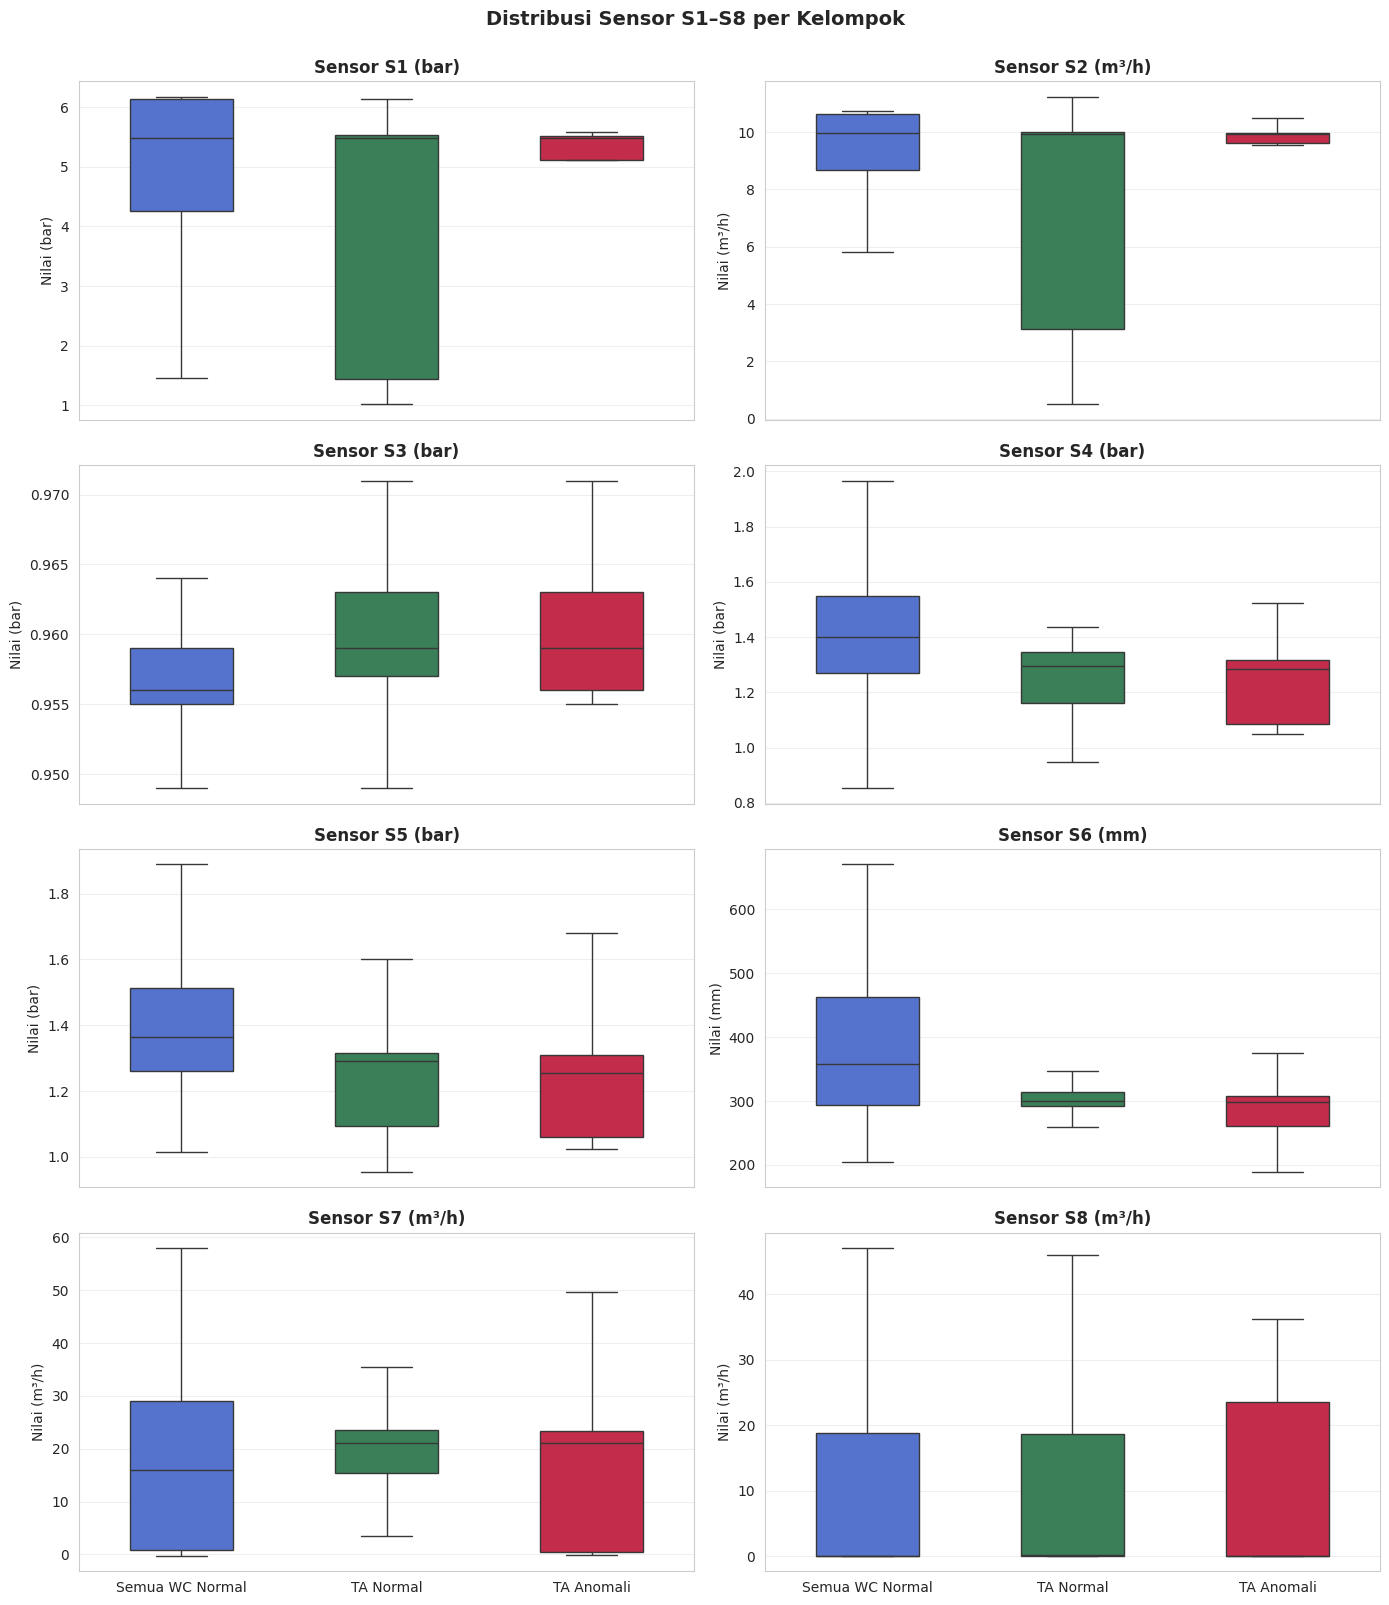

Disimpan: /kaggle/working/eda_final/03_boxplot_sensors_all_wc.png


In [5]:
# ============================================================
# Data dictionary untuk 3 kelompok dengan referensi Semua WC
# ============================================================
data_3groups_all_wc = {
    "Semua WC Normal": df_wc_all,
    "TA Normal":       df_ta_normal,
    "TA Anomali":      df_ta_anomali,
}

plot_boxplot_sensors(
    data_dict=data_3groups_all_wc,
    colors=COLORS,
    title="Distribusi Sensor S1–S8 per Kelompok",
    output_path=OUTPUT_DIR / "03_boxplot_sensors_all_wc.png",
)

# 2 - Multivariat

## 2.1 — Full pair plot 8×8 (referensi WC1)

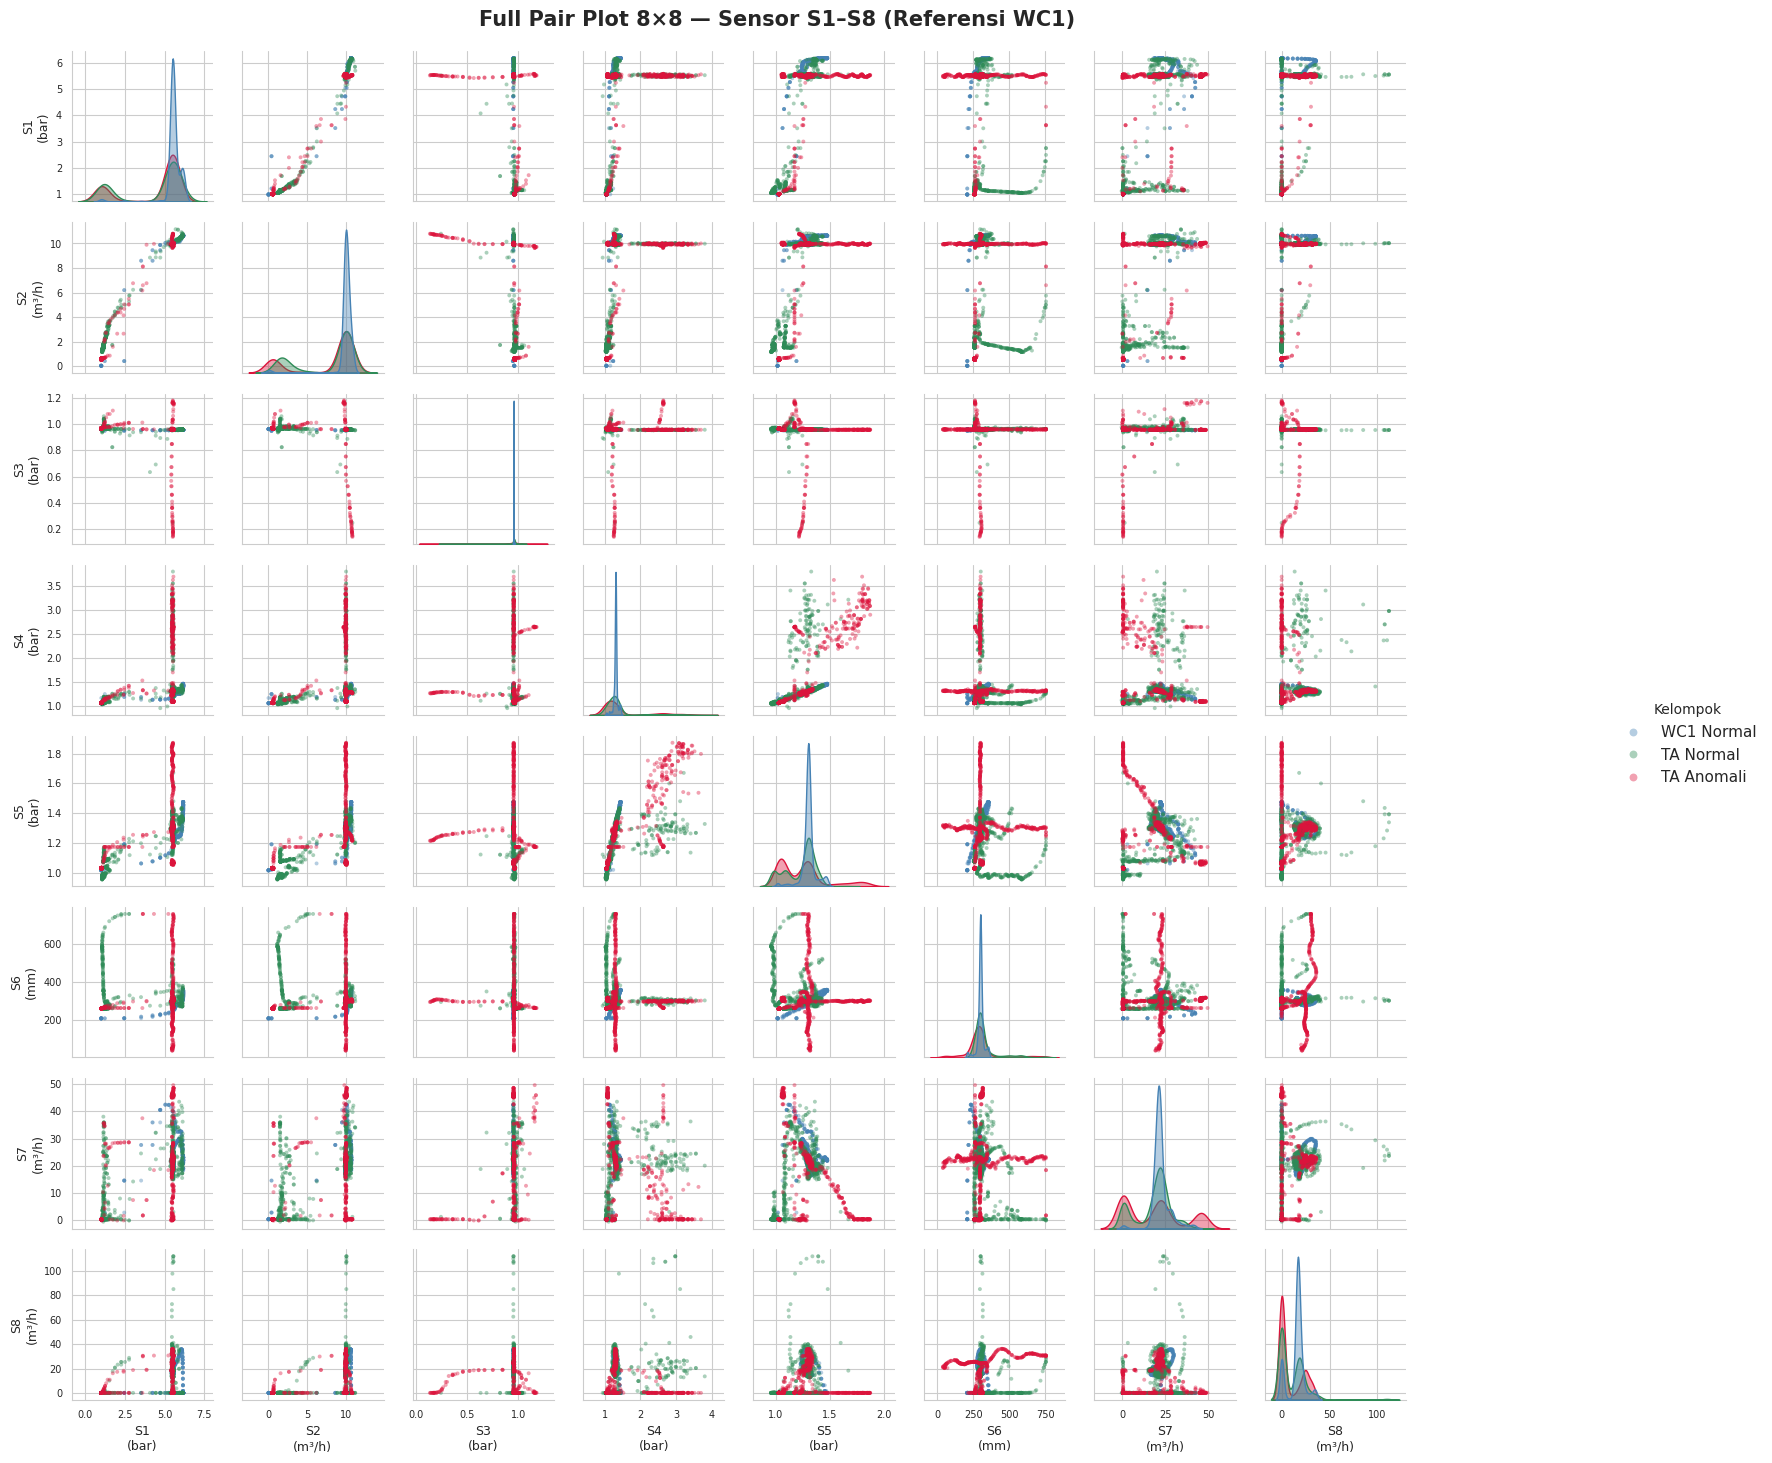

Disimpan: /kaggle/working/eda_final/08_full_pairplot_wc1.png


In [6]:
def plot_full_pairplot(
    data_dict: dict,
    colors: dict,
    title: str,
    output_path: Path,
    n_sample: int = 1000,
):
    """
    Full pair plot 8x8 untuk semua sensor S1-S8.
    Dirancang untuk lampiran — subplot kecil tapi cakupan lengkap.
    """
    # Downsampling per kelompok + gabung
    parts = []
    for kelompok, df in data_dict.items():
        n = min(n_sample, len(df))
        sample = df[SENSOR_COLS].sample(n=n, random_state=SEED).copy()
        sample["Kelompok"] = kelompok
        parts.append(sample)
    df_combined = pd.concat(parts, ignore_index=True)
    
    kelompok_order = list(data_dict.keys())
    palette = {k: colors[k] for k in kelompok_order}
    
    g = sns.PairGrid(
        df_combined,
        vars=SENSOR_COLS,
        hue="Kelompok",
        hue_order=kelompok_order,
        palette=palette,
        height=1.8,
        diag_sharey=False,
    )
    
    # Diagonal: KDE
    g.map_diag(sns.kdeplot, fill=True, alpha=0.4, common_norm=False, linewidth=1.0)
    
    # Off-diagonal: scatter (marker lebih kecil dari focused version)
    g.map_offdiag(sns.scatterplot, s=8, alpha=0.4, edgecolor="none")
    
    # Label sumbu dengan satuan
    for i, sensor_y in enumerate(SENSOR_COLS):
        for j, sensor_x in enumerate(SENSOR_COLS):
            ax = g.axes[i, j]
            unit_y = SENSOR_UNITS.get(sensor_y, "")
            unit_x = SENSOR_UNITS.get(sensor_x, "")
            if j == 0:  # kolom kiri: label Y
                ax.set_ylabel(f"{sensor_y}\n({unit_y})", fontsize=9)
            if i == len(SENSOR_COLS) - 1:  # baris bawah: label X
                ax.set_xlabel(f"{sensor_x}\n({unit_x})", fontsize=9)
            ax.tick_params(labelsize=7)
    
    g.add_legend(
        title="Kelompok",
        fontsize=11,
        title_fontsize=12,
        bbox_to_anchor=(1.02, 0.5),
        loc="center left",
        markerscale=2.0,
    )
    
    g.fig.suptitle(title, fontsize=15, fontweight="bold", y=1.01)
    
    plt.savefig(output_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Disimpan: {output_path}")


# ============================================================
# Full pair plot referensi WC1
# ============================================================
plot_full_pairplot(
    data_dict=data_3groups,  # WC1, TA Normal, TA Anomali
    colors=COLORS,
    title="Full Pair Plot 8×8 — Sensor S1–S8 (Referensi WC1)",
    output_path=OUTPUT_DIR / "08_full_pairplot_wc1.png",
    n_sample=1000,
)

## 2.2 — Full pair plot 8×8 (referensi Semua WC)

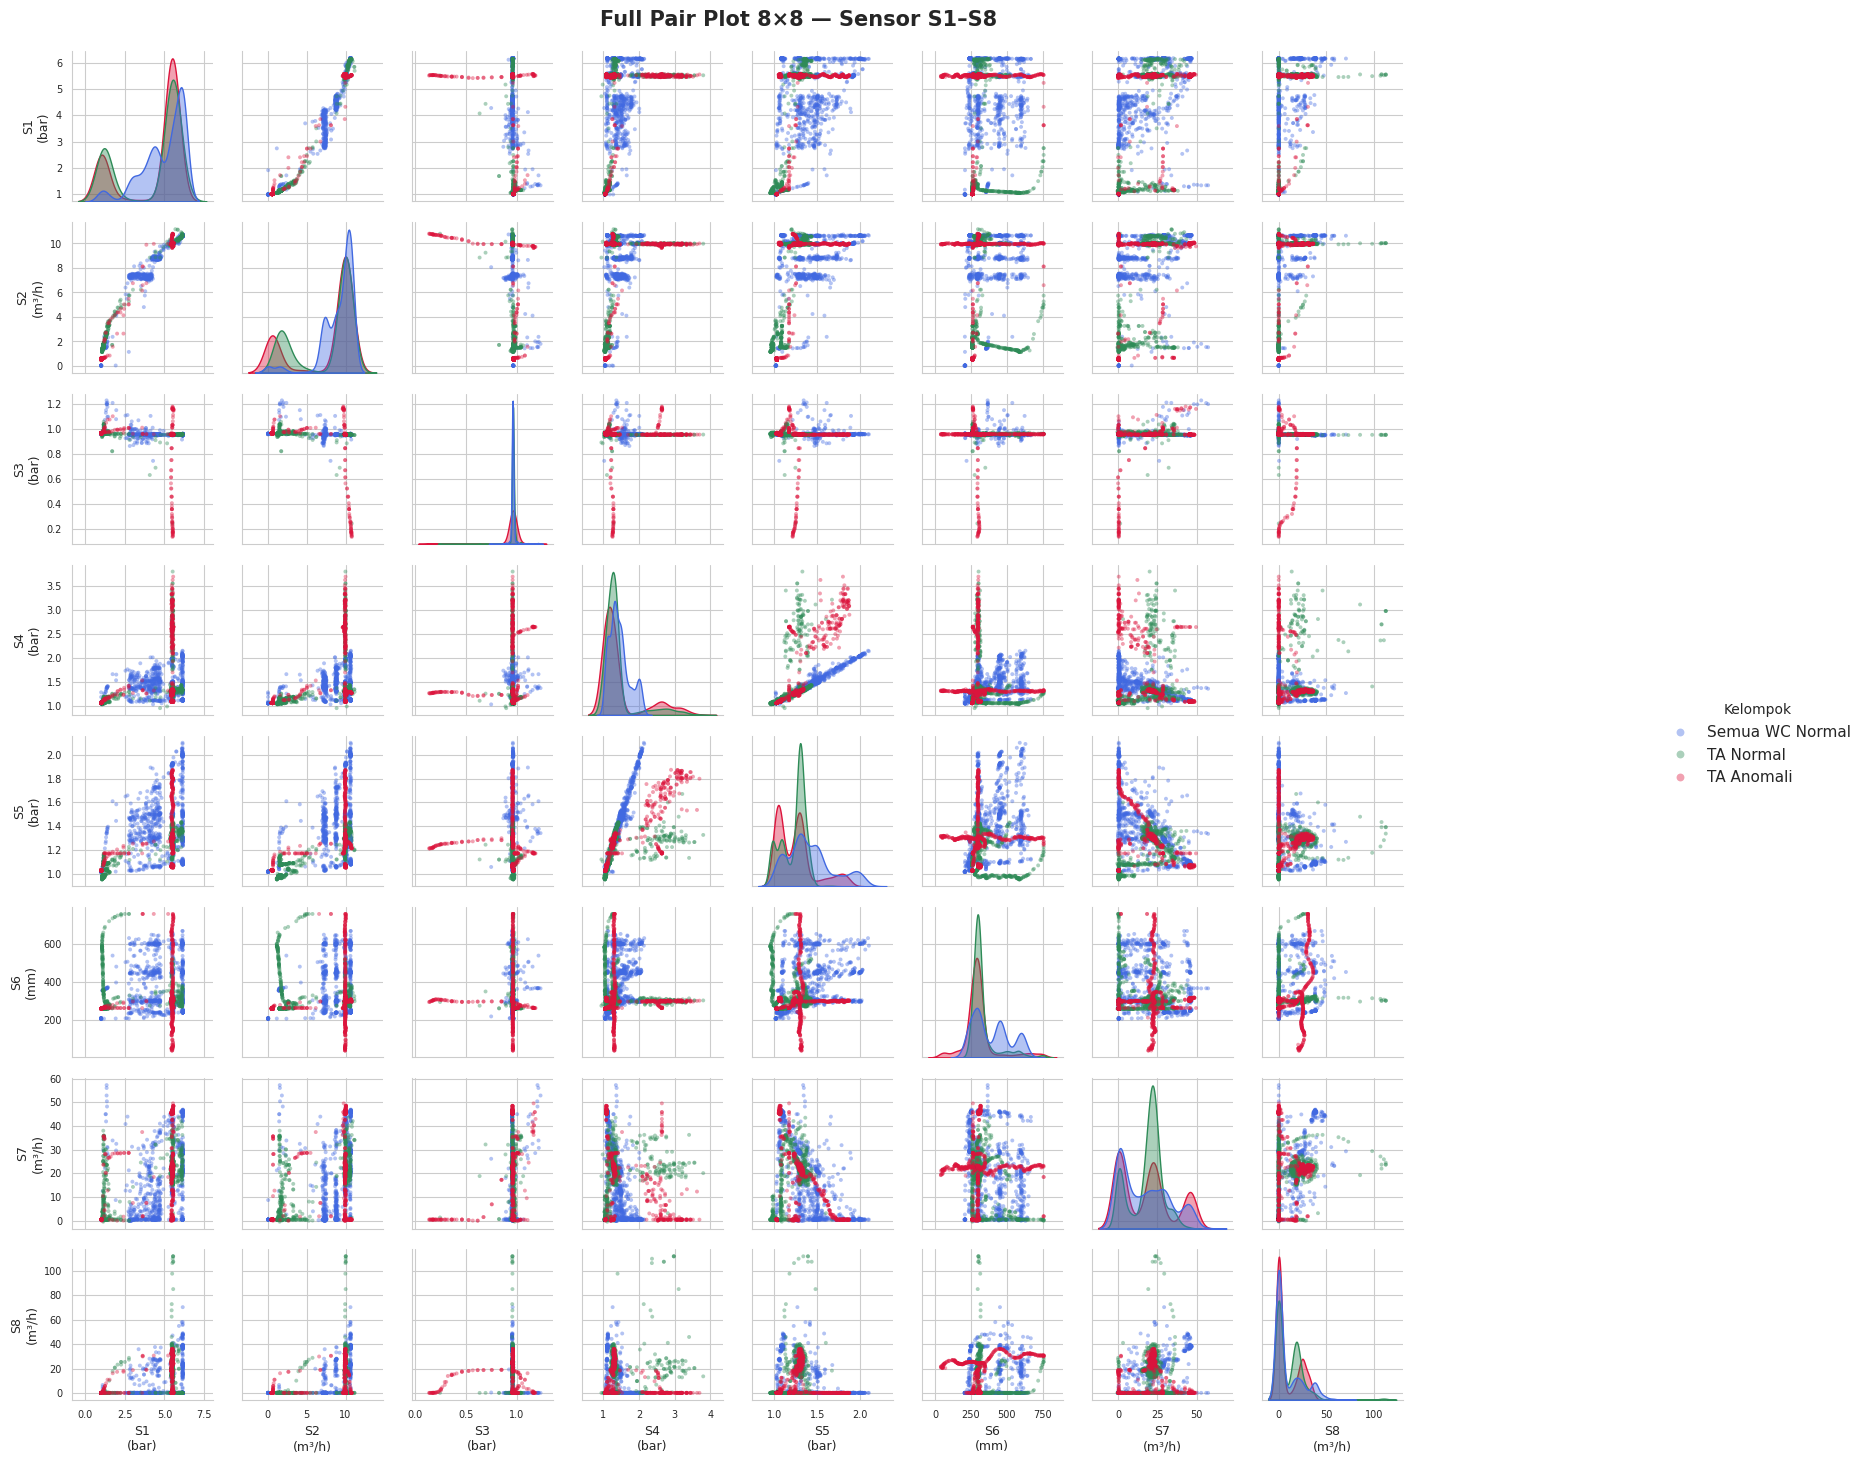

Disimpan: /kaggle/working/eda_final/09_full_pairplot_all_wc.png


In [7]:
# ============================================================
# Full pair plot referensi Semua WC
# ============================================================
plot_full_pairplot(
    data_dict=data_3groups_all_wc,  # Semua WC, TA Normal, TA Anomali
    colors=COLORS,
    title="Full Pair Plot 8×8 — Sensor S1–S8",
    output_path=OUTPUT_DIR / "09_full_pairplot_all_wc.png",
    n_sample=1000,
)

## 2.3 - Focused pair plot 4×4 (S1, S3, S5, S8, referensi WC1)

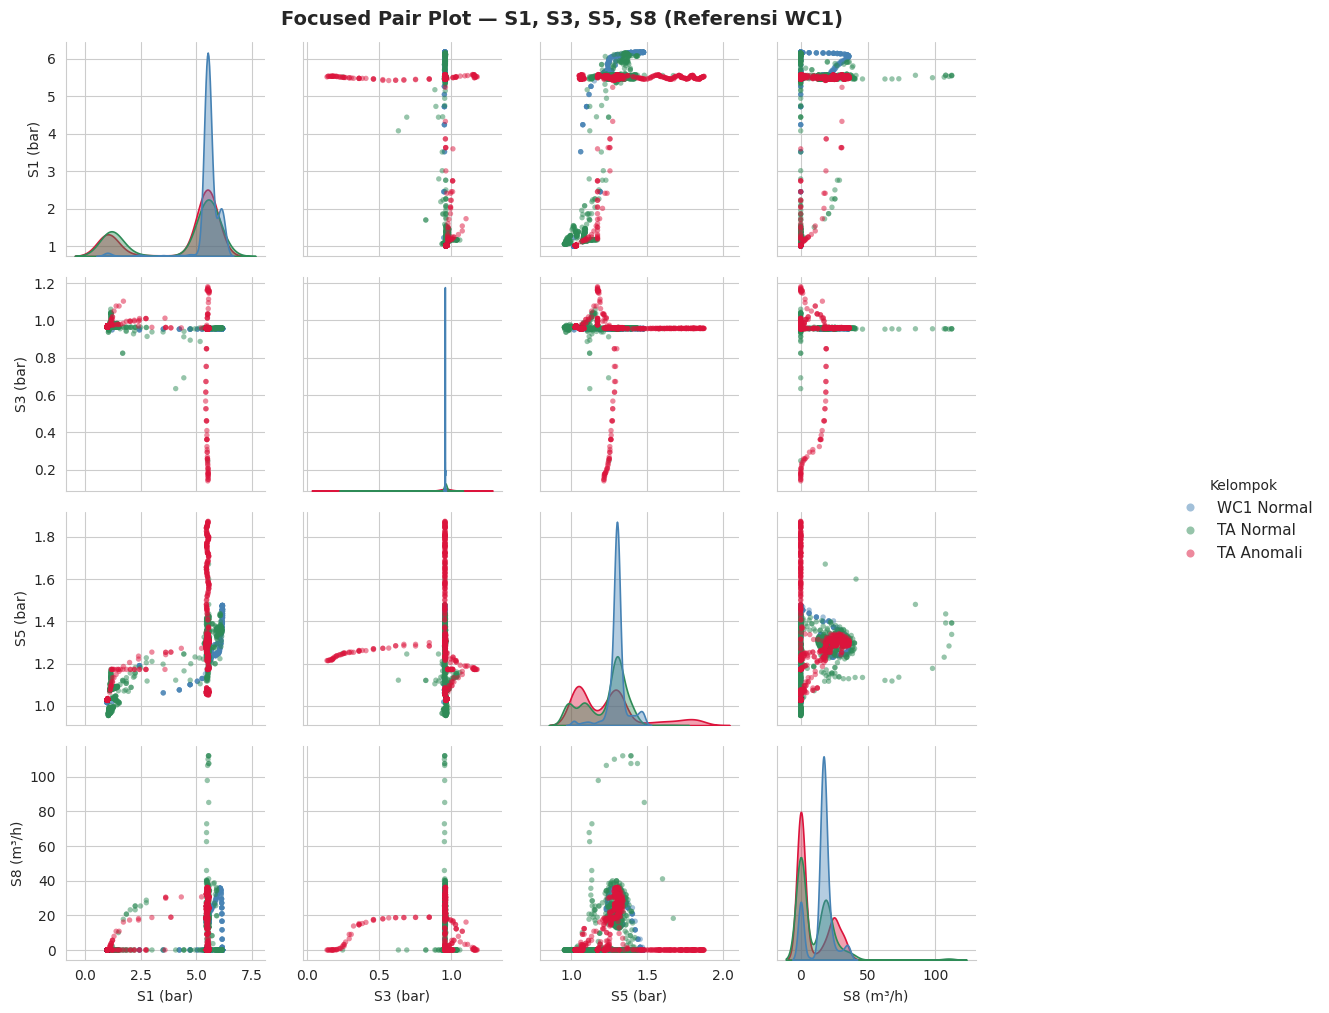

Disimpan: /kaggle/working/eda_final/04_focused_pairplot_wc1.png


In [8]:
def plot_focused_pairplot(
    data_dict: dict,
    colors: dict,
    sensors: list,
    title: str,
    output_path: Path,
    n_sample: int = 1000,
):
    """
    Focused pair plot untuk subset sensor terpilih.
    
    - Diagonal: KDE distribusi per sensor
    - Off-diagonal: scatter antar pasangan sensor
    - Warna: per kelompok
    - Downsampling per kelompok untuk mencegah overplot
    """
    # Downsampling per kelompok + gabung
    parts = []
    for kelompok, df in data_dict.items():
        n = min(n_sample, len(df))
        sample = df[sensors].sample(n=n, random_state=SEED).copy()
        sample["Kelompok"] = kelompok
        parts.append(sample)
    df_combined = pd.concat(parts, ignore_index=True)
    
    # Palette sesuai urutan kelompok
    kelompok_order = list(data_dict.keys())
    palette = {k: colors[k] for k in kelompok_order}
    
    # Pair plot menggunakan seaborn PairGrid
    g = sns.PairGrid(
        df_combined,
        vars=sensors,
        hue="Kelompok",
        hue_order=kelompok_order,
        palette=palette,
        height=2.5,
        diag_sharey=False,
    )
    
    # Diagonal: KDE
    g.map_diag(sns.kdeplot, fill=True, alpha=0.4, common_norm=False, linewidth=1.2)
    
    # Off-diagonal: scatter
    g.map_offdiag(sns.scatterplot, s=15, alpha=0.5, edgecolor="none")
    
    # Label sumbu dengan satuan
    for i, sensor_y in enumerate(sensors):
        for j, sensor_x in enumerate(sensors):
            ax = g.axes[i, j]
            unit_y = SENSOR_UNITS.get(sensor_y, "")
            unit_x = SENSOR_UNITS.get(sensor_x, "")
            if j == 0:  # kolom kiri: label Y
                ax.set_ylabel(f"{sensor_y} ({unit_y})", fontsize=10)
            if i == len(sensors) - 1:  # baris bawah: label X
                ax.set_xlabel(f"{sensor_x} ({unit_x})", fontsize=10)
    
    # Legenda
    g.add_legend(
        title="Kelompok",
        fontsize=11,
        title_fontsize=12,
        bbox_to_anchor=(1.02, 0.5),
        loc="center left",
        markerscale=1.5,
    )
    
    # Title
    g.fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Disimpan: {output_path}")


# ============================================================
# Sensor terpilih berdasarkan alur sistem Mazzuto (Array 2025)
# ============================================================
FOCUSED_SENSORS = ["S1", "S3", "S5", "S8"]
# S1 = Inlet water pressure (input)
# S3 = Ejector pressure (subsistem ejector, coupling dengan S1 via Bernoulli)
# S5 = Tank pressure (subsistem tank, dikontrol PID3)
# S8 = Outlet air flow (output akhir sistem)

# ============================================================
# Pair plot referensi WC1
# ============================================================
plot_focused_pairplot(
    data_dict=data_3groups,  # WC1, TA Normal, TA Anomali (dari Cell 1.2)
    colors=COLORS,
    sensors=FOCUSED_SENSORS,
    title="Focused Pair Plot — S1, S3, S5, S8 (Referensi WC1)",
    output_path=OUTPUT_DIR / "04_focused_pairplot_wc1.png",
    n_sample=1000,
)

## 2.4 — Focused pair plot 4×4 (S1, S3, S5, S8, referensi Semua WC)

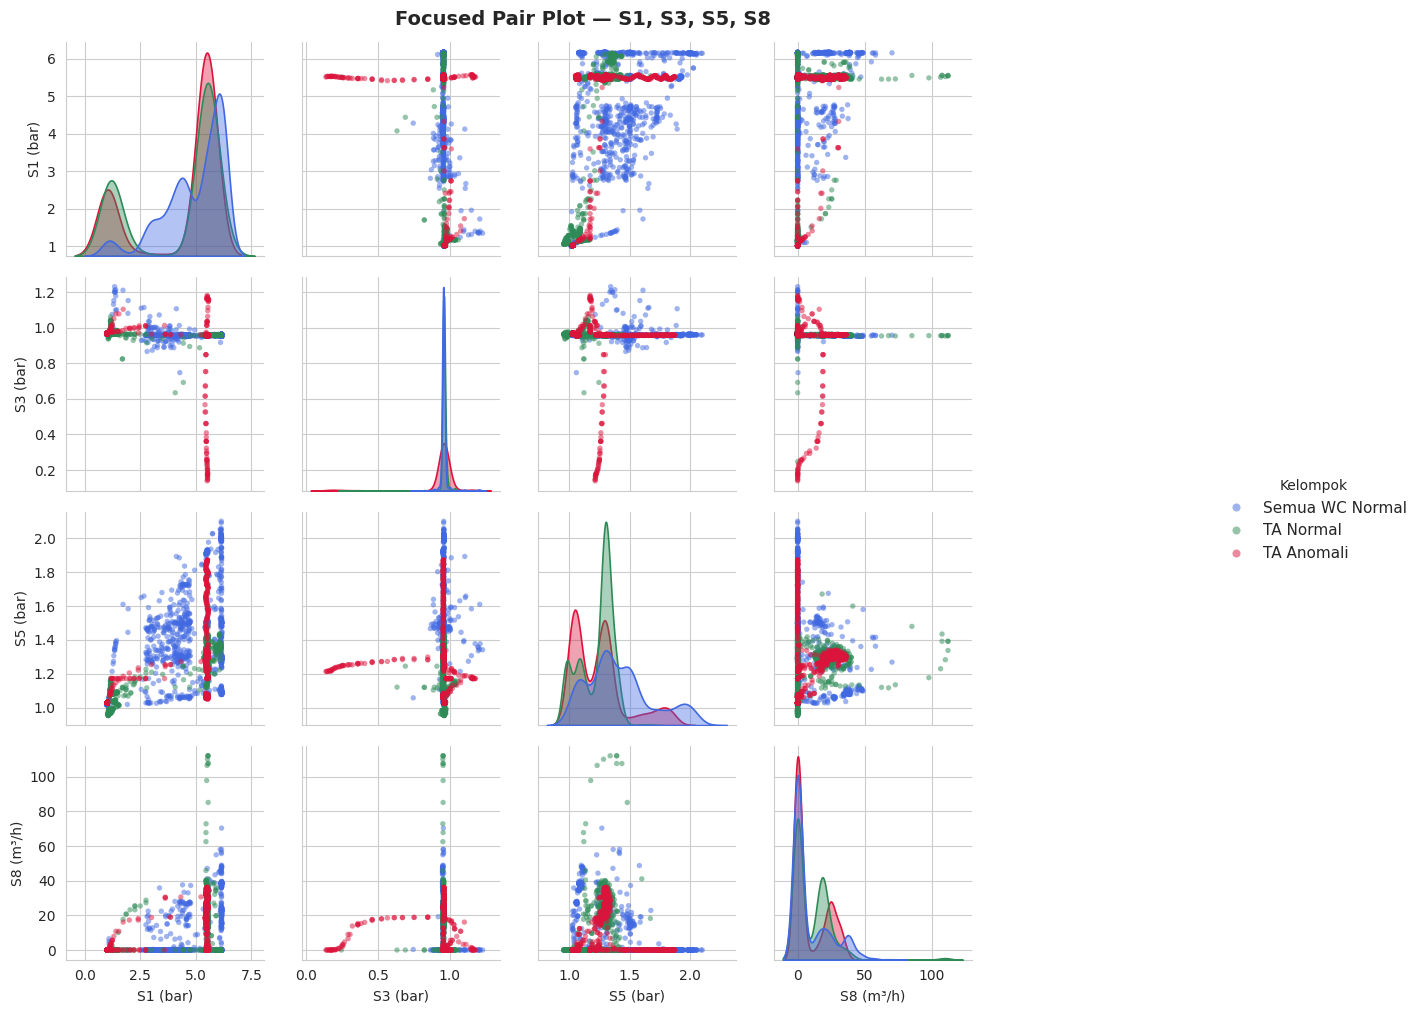

Disimpan: /kaggle/working/eda_final/05_focused_pairplot_all_wc.png


In [9]:
# ============================================================
# Focused pair plot referensi Semua WC
# ============================================================
plot_focused_pairplot(
    data_dict=data_3groups_all_wc,  # Semua WC, TA Normal, TA Anomali (dari Cell 1.3)
    colors=COLORS,
    sensors=FOCUSED_SENSORS,
    title="Focused Pair Plot — S1, S3, S5, S8",
    output_path=OUTPUT_DIR / "05_focused_pairplot_all_wc.png",
    n_sample=1000,
)

## 2.5 — PCA scatter + loadings (referensi WC1)

Explained variance PC1  : 55.55%
Explained variance PC2  : 23.60%
Total explained variance: 79.15%


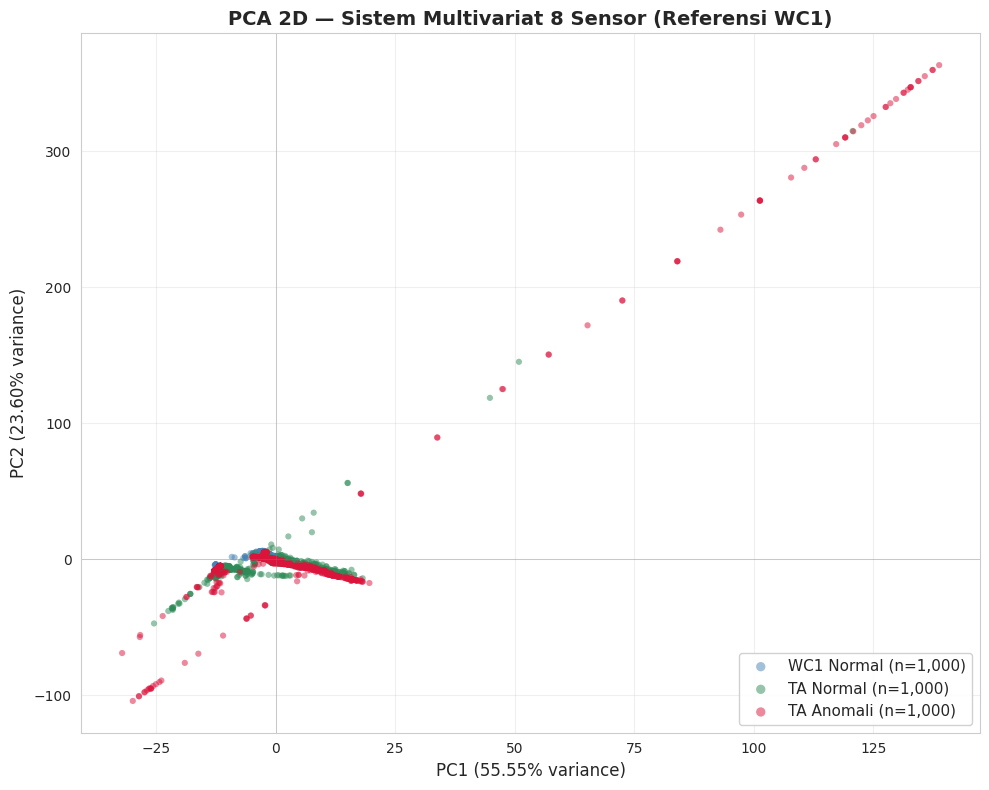

Disimpan: /kaggle/working/eda_final/06_pca_scatter_wc1.png

Loadings — Kontribusi Sensor ke PC1 dan PC2:
     PC1   PC2  |PC1|  |PC2|
S1 +0.45 +0.16  +0.45  +0.16
S2 +0.43 +0.23  +0.43  +0.23
S3 -0.20 -0.51  +0.20  +0.51
S4 +0.41 -0.30  +0.41  +0.30
S5 +0.43 -0.27  +0.43  +0.27
S6 +0.42 -0.32  +0.42  +0.32
S7 +0.17 +0.63  +0.17  +0.63
S8 +0.11 -0.01  +0.11  +0.01

Disimpan: /kaggle/working/eda_final/06_pca_loadings_wc1.csv


In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


def plot_pca_scatter(
    data_dict: dict,
    colors: dict,
    reference_key: str,
    title: str,
    output_path_scatter: Path,
    output_path_loadings: Path,
    n_sample: int = 1000,
):
    """
    PCA 2D scatter untuk visualisasi sistem 8-sensor secara holistik.
    
    Metodologi (bebas leakage):
    - Scaler di-fit HANYA pada reference group (kondisi normal)
    - PCA di-fit HANYA pada reference group
    - Semua kelompok (termasuk anomali) di-transform pakai scaler & PCA yang sama
    
    Output:
    - Scatter 2D PC1 vs PC2 dengan hue per kelompok
    - Tabel loadings (kontribusi sensor ke PC1 dan PC2)
    """
    # ============================================================
    # 1. Fit scaler dan PCA HANYA di reference group
    # ============================================================
    ref_data = data_dict[reference_key][SENSOR_COLS].values
    
    scaler = StandardScaler()
    scaler.fit(ref_data)
    ref_scaled = scaler.transform(ref_data)
    
    pca = PCA(n_components=2, random_state=SEED)
    pca.fit(ref_scaled)
    
    # ============================================================
    # 2. Transform semua kelompok pakai scaler & PCA reference
    # ============================================================
    transformed = {}
    for kelompok, df in data_dict.items():
        # Downsampling per kelompok
        n = min(n_sample, len(df))
        sample = df[SENSOR_COLS].sample(n=n, random_state=SEED).values
        sample_scaled = scaler.transform(sample)
        transformed[kelompok] = pca.transform(sample_scaled)
    
    # Explained variance
    ev_pc1 = pca.explained_variance_ratio_[0] * 100
    ev_pc2 = pca.explained_variance_ratio_[1] * 100
    ev_total = ev_pc1 + ev_pc2
    
    print(f"Explained variance PC1  : {ev_pc1:.2f}%")
    print(f"Explained variance PC2  : {ev_pc2:.2f}%")
    print(f"Total explained variance: {ev_total:.2f}%")
    
    # ============================================================
    # 3. Plot scatter
    # ============================================================
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot urutan kelompok: yang paling padat dulu (di bawah), sparse di atas
    plot_order = sorted(transformed.keys(), key=lambda k: -len(transformed[k]))
    
    for kelompok in plot_order:
        points = transformed[kelompok]
        ax.scatter(
            points[:, 0], points[:, 1],
            s=20, alpha=0.5,
            color=colors[kelompok],
            edgecolor="none",
            label=f"{kelompok} (n={len(points):,})",
        )
    
    ax.set_xlabel(f"PC1 ({ev_pc1:.2f}% variance)", fontsize=12)
    ax.set_ylabel(f"PC2 ({ev_pc2:.2f}% variance)", fontsize=12)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.legend(fontsize=11, markerscale=1.5, loc="best", framealpha=0.9)
    ax.grid(alpha=0.3)
    ax.axhline(0, color="gray", linewidth=0.5, alpha=0.5)
    ax.axvline(0, color="gray", linewidth=0.5, alpha=0.5)
    
    plt.tight_layout()
    plt.savefig(output_path_scatter, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Disimpan: {output_path_scatter}")
    
    # ============================================================
    # 4. Tabel loadings — kontribusi tiap sensor ke PC1 dan PC2
    # ============================================================
    loadings = pd.DataFrame(
        pca.components_.T,
        columns=["PC1", "PC2"],
        index=SENSOR_COLS,
    )
    loadings["|PC1|"] = loadings["PC1"].abs()
    loadings["|PC2|"] = loadings["PC2"].abs()
    
    print("\nLoadings — Kontribusi Sensor ke PC1 dan PC2:")
    print("=" * 60)
    print(loadings.to_string(float_format=lambda v: f"{v:+.2f}"))
    
    loadings.to_csv(output_path_loadings)
    print(f"\nDisimpan: {output_path_loadings}")
    
    return loadings, ev_total


# ============================================================
# PCA referensi WC1
# ============================================================
loadings_wc1, ev_total_wc1 = plot_pca_scatter(
    data_dict=data_3groups,  # WC1, TA Normal, TA Anomali (dari Cell 1.2)
    colors=COLORS,
    reference_key="WC1 Normal",
    title="PCA 2D — Sistem Multivariat 8 Sensor (Referensi WC1)",
    output_path_scatter=OUTPUT_DIR / "06_pca_scatter_wc1.png",
    output_path_loadings=OUTPUT_DIR / "06_pca_loadings_wc1.csv",
    n_sample=1000,
)

## 2.6 — PCA scatter + loadings (referensi Semua WC)

Explained variance PC1  : 38.67%
Explained variance PC2  : 30.17%
Total explained variance: 68.84%


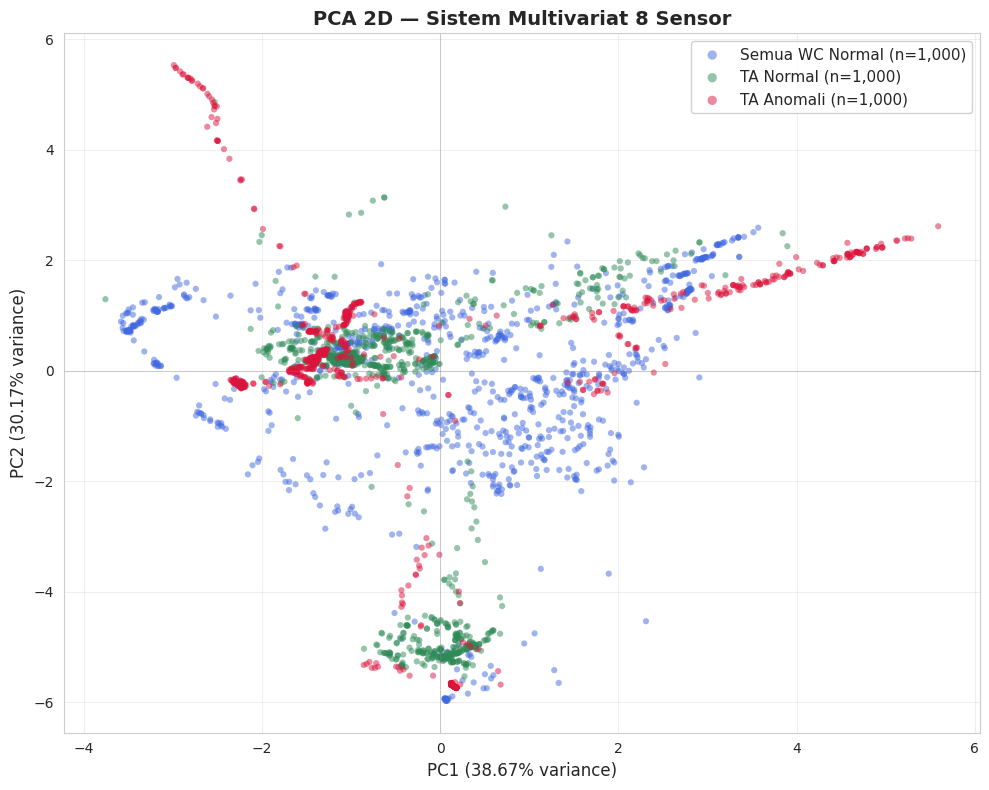

Disimpan: /kaggle/working/eda_final/07_pca_scatter_all_wc.png

Loadings — Kontribusi Sensor ke PC1 dan PC2:
     PC1   PC2  |PC1|  |PC2|
S1 -0.15 +0.60  +0.15  +0.60
S2 -0.11 +0.60  +0.11  +0.60
S3 +0.09 -0.17  +0.09  +0.17
S4 +0.51 +0.24  +0.51  +0.24
S5 +0.49 +0.29  +0.49  +0.29
S6 +0.18 +0.23  +0.18  +0.23
S7 -0.50 +0.12  +0.50  +0.12
S8 -0.42 +0.18  +0.42  +0.18

Disimpan: /kaggle/working/eda_final/07_pca_loadings_all_wc.csv


In [11]:
# ============================================================
# PCA referensi Semua WC
# ============================================================
loadings_all_wc, ev_total_all_wc = plot_pca_scatter(
    data_dict=data_3groups_all_wc,  # Semua WC, TA Normal, TA Anomali (dari Cell 1.3)
    colors=COLORS,
    reference_key="Semua WC Normal",
    title="PCA 2D — Sistem Multivariat 8 Sensor",
    output_path_scatter=OUTPUT_DIR / "07_pca_scatter_all_wc.png",
    output_path_loadings=OUTPUT_DIR / "07_pca_loadings_all_wc.csv",
    n_sample=1000,
)

## 2.7 - Subplot Time-Series S1-S8

  2.7 — SUBPLOT TIME-SERIES S1–S8 PER FILE TA SEVERE

[VM1_severe]  N=2,627  Normal=1,020  Anomali=1,607


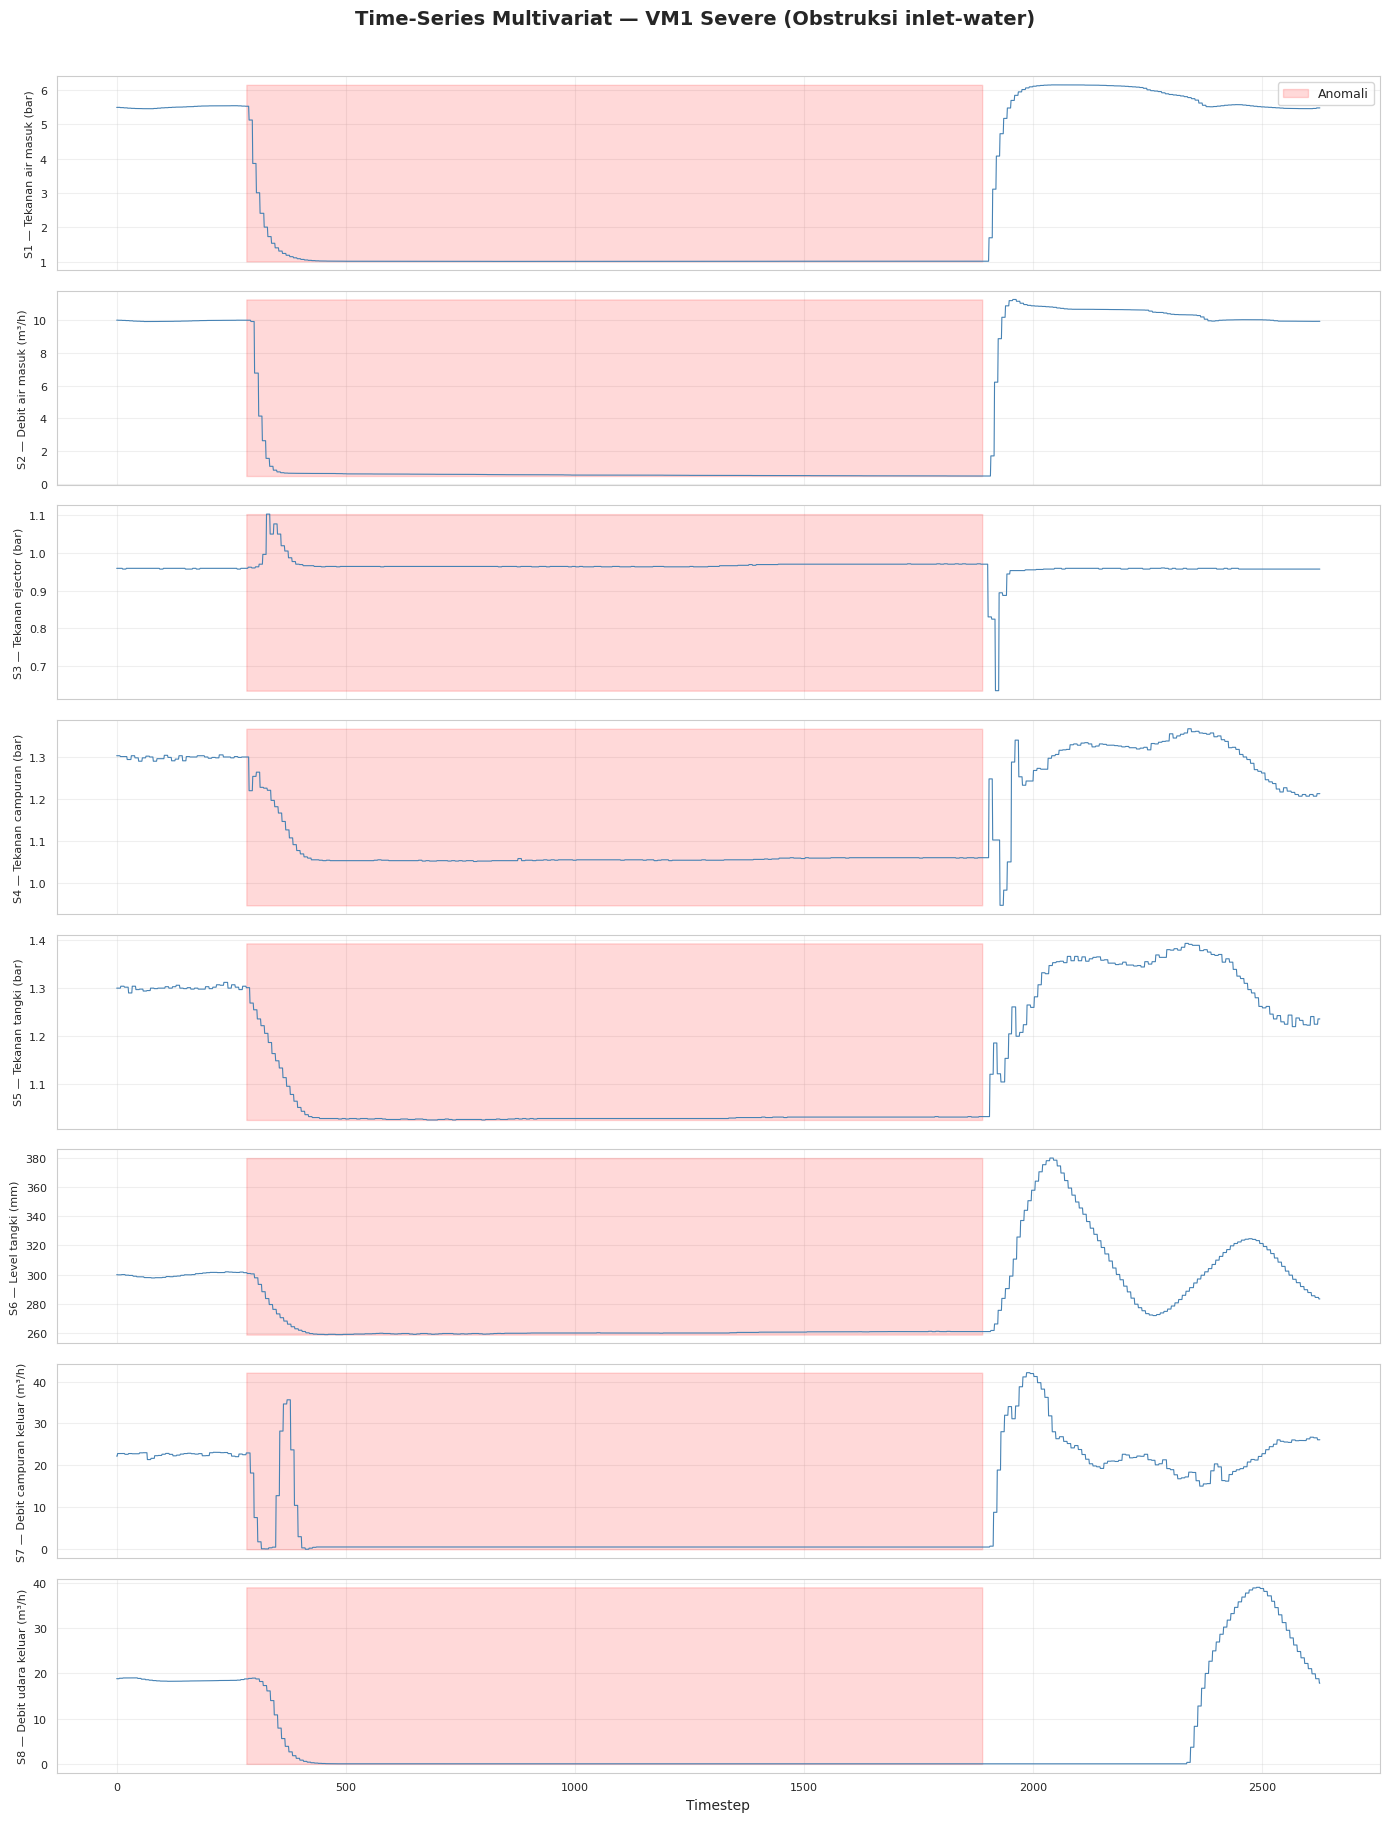

Disimpan: /kaggle/working/eda_final/12_timeseries_VM1_severe.png

[VM2_severe]  N=2,764  Normal=2,377  Anomali=387


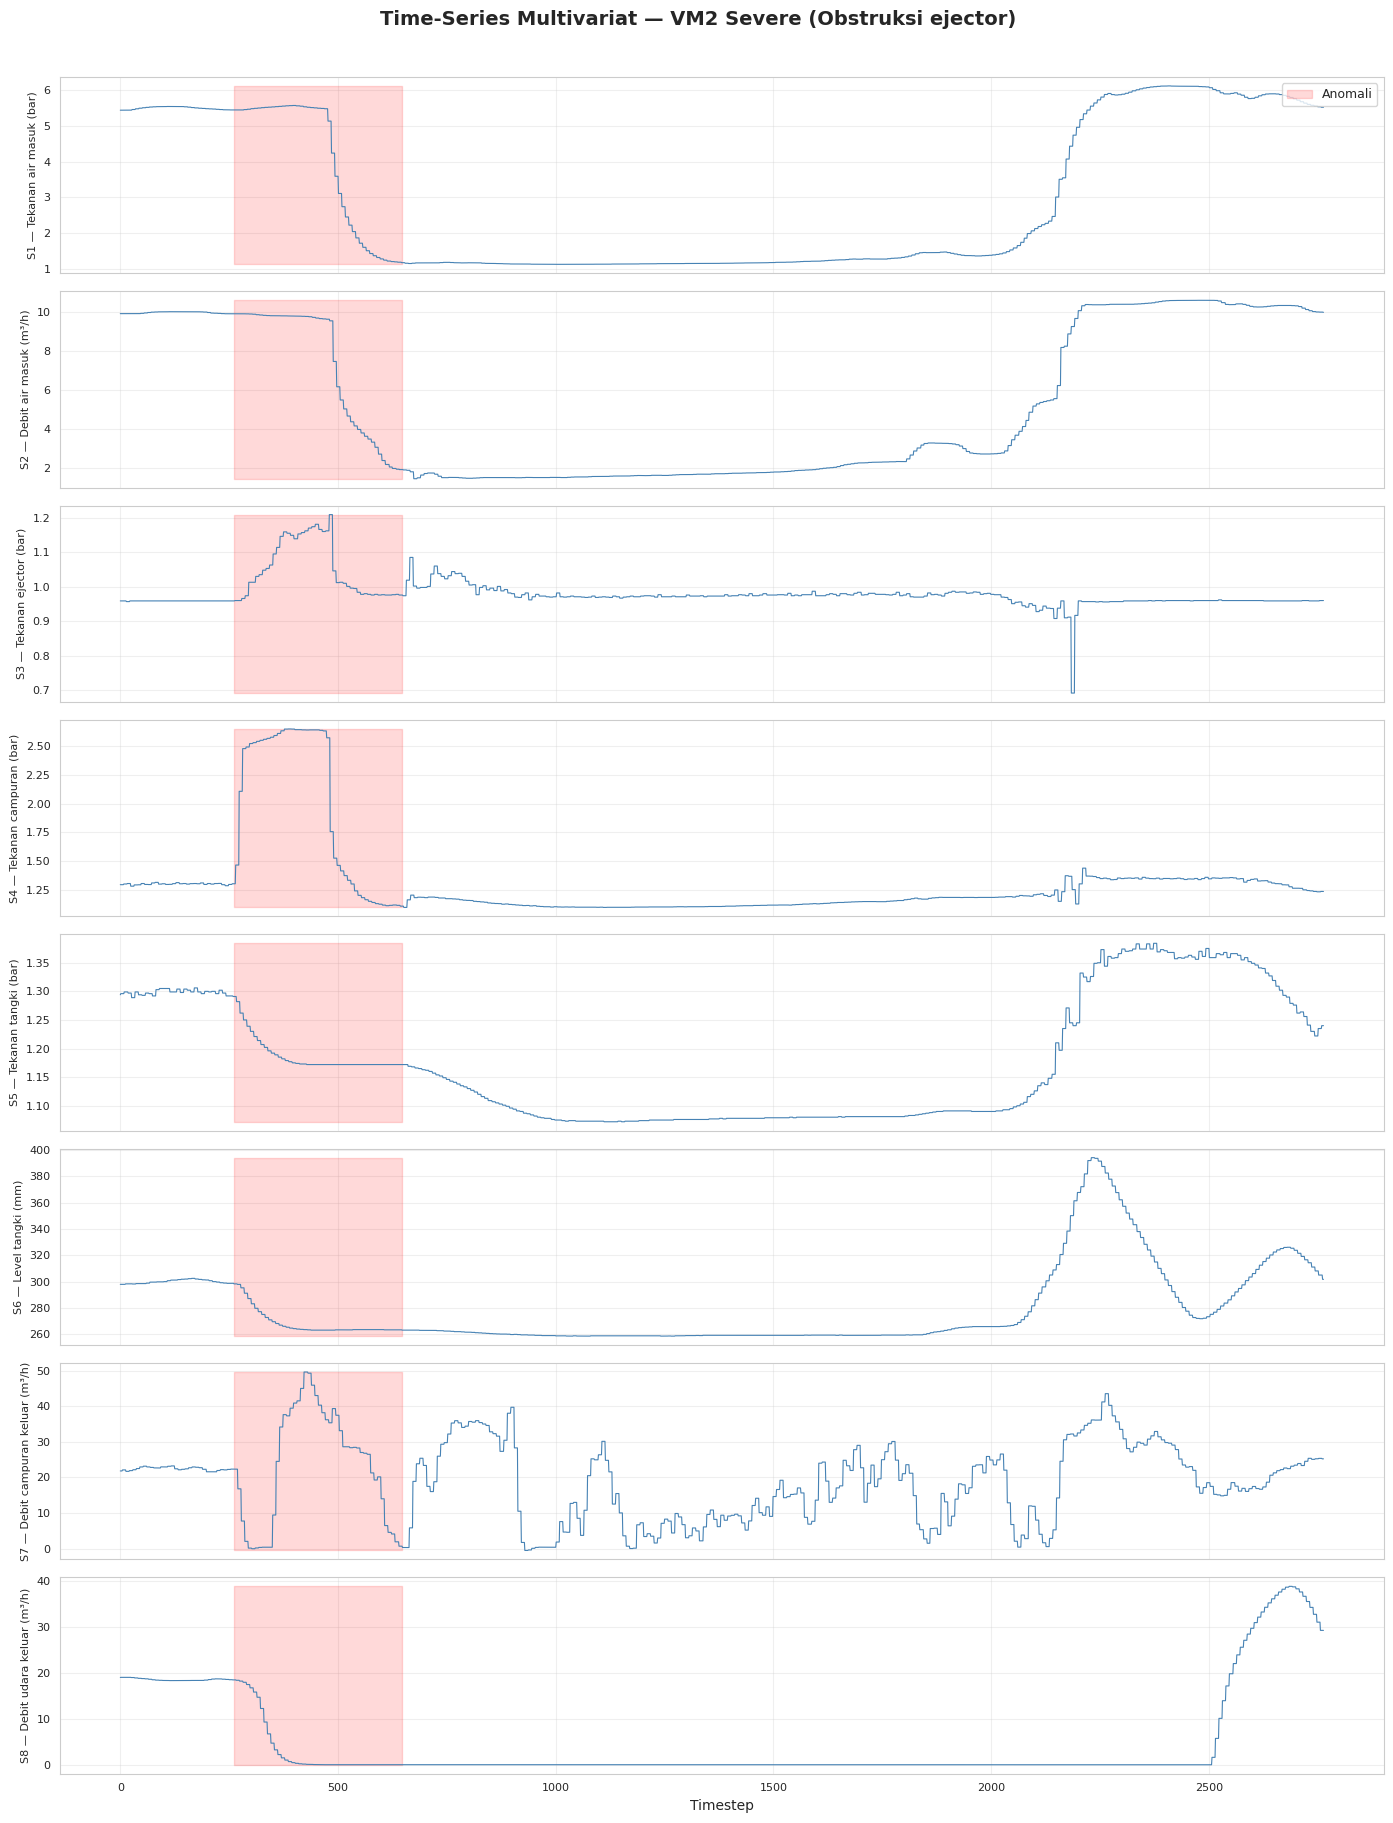

Disimpan: /kaggle/working/eda_final/12_timeseries_VM2_severe.png

[VM3_severe]  N=3,392  Normal=2,529  Anomali=863


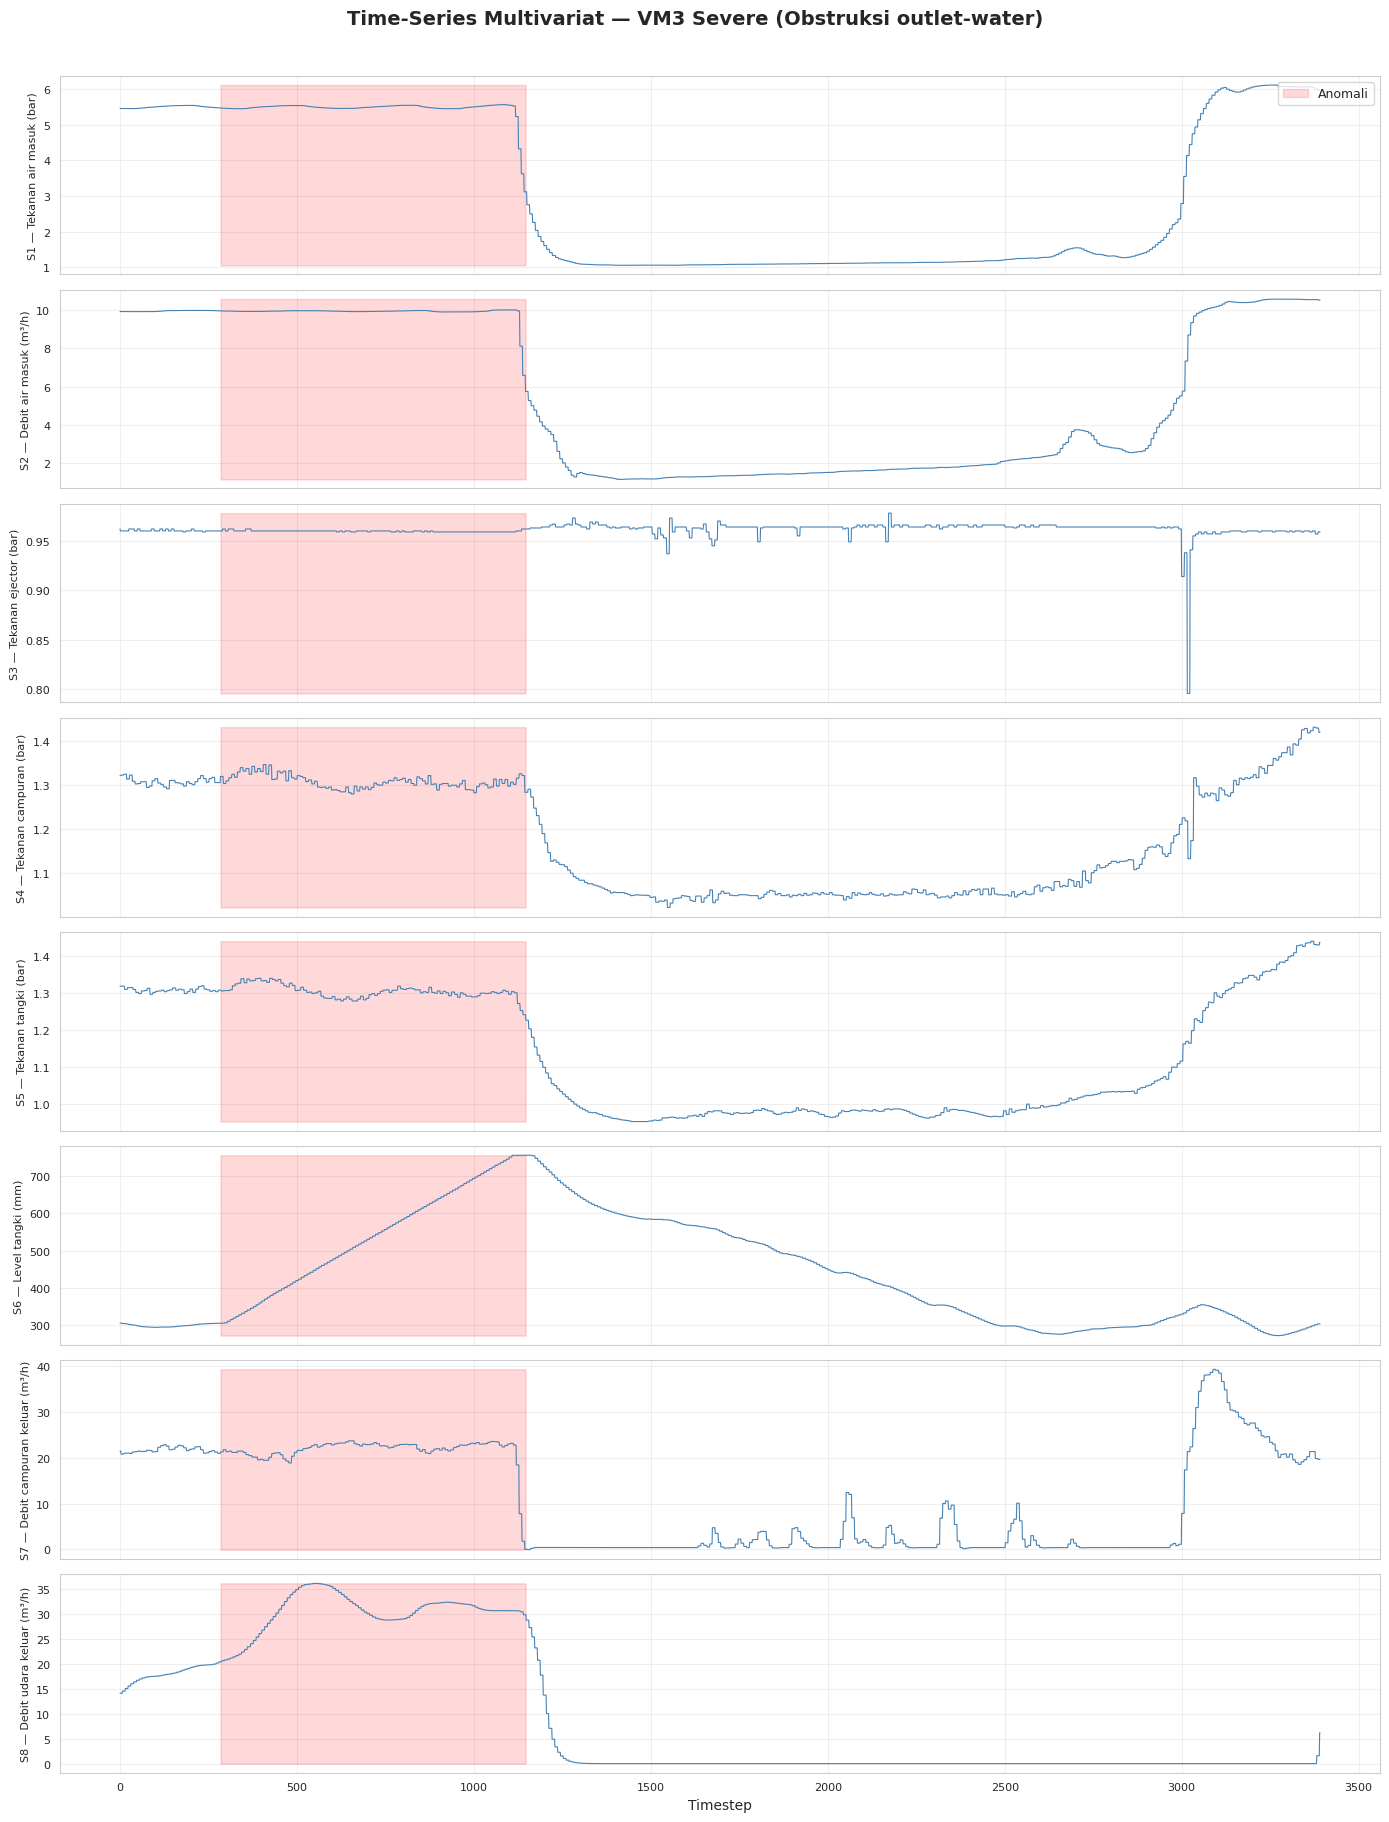

Disimpan: /kaggle/working/eda_final/12_timeseries_VM3_severe.png

[VM4_severe]  N=2,542  Normal=1,045  Anomali=1,497


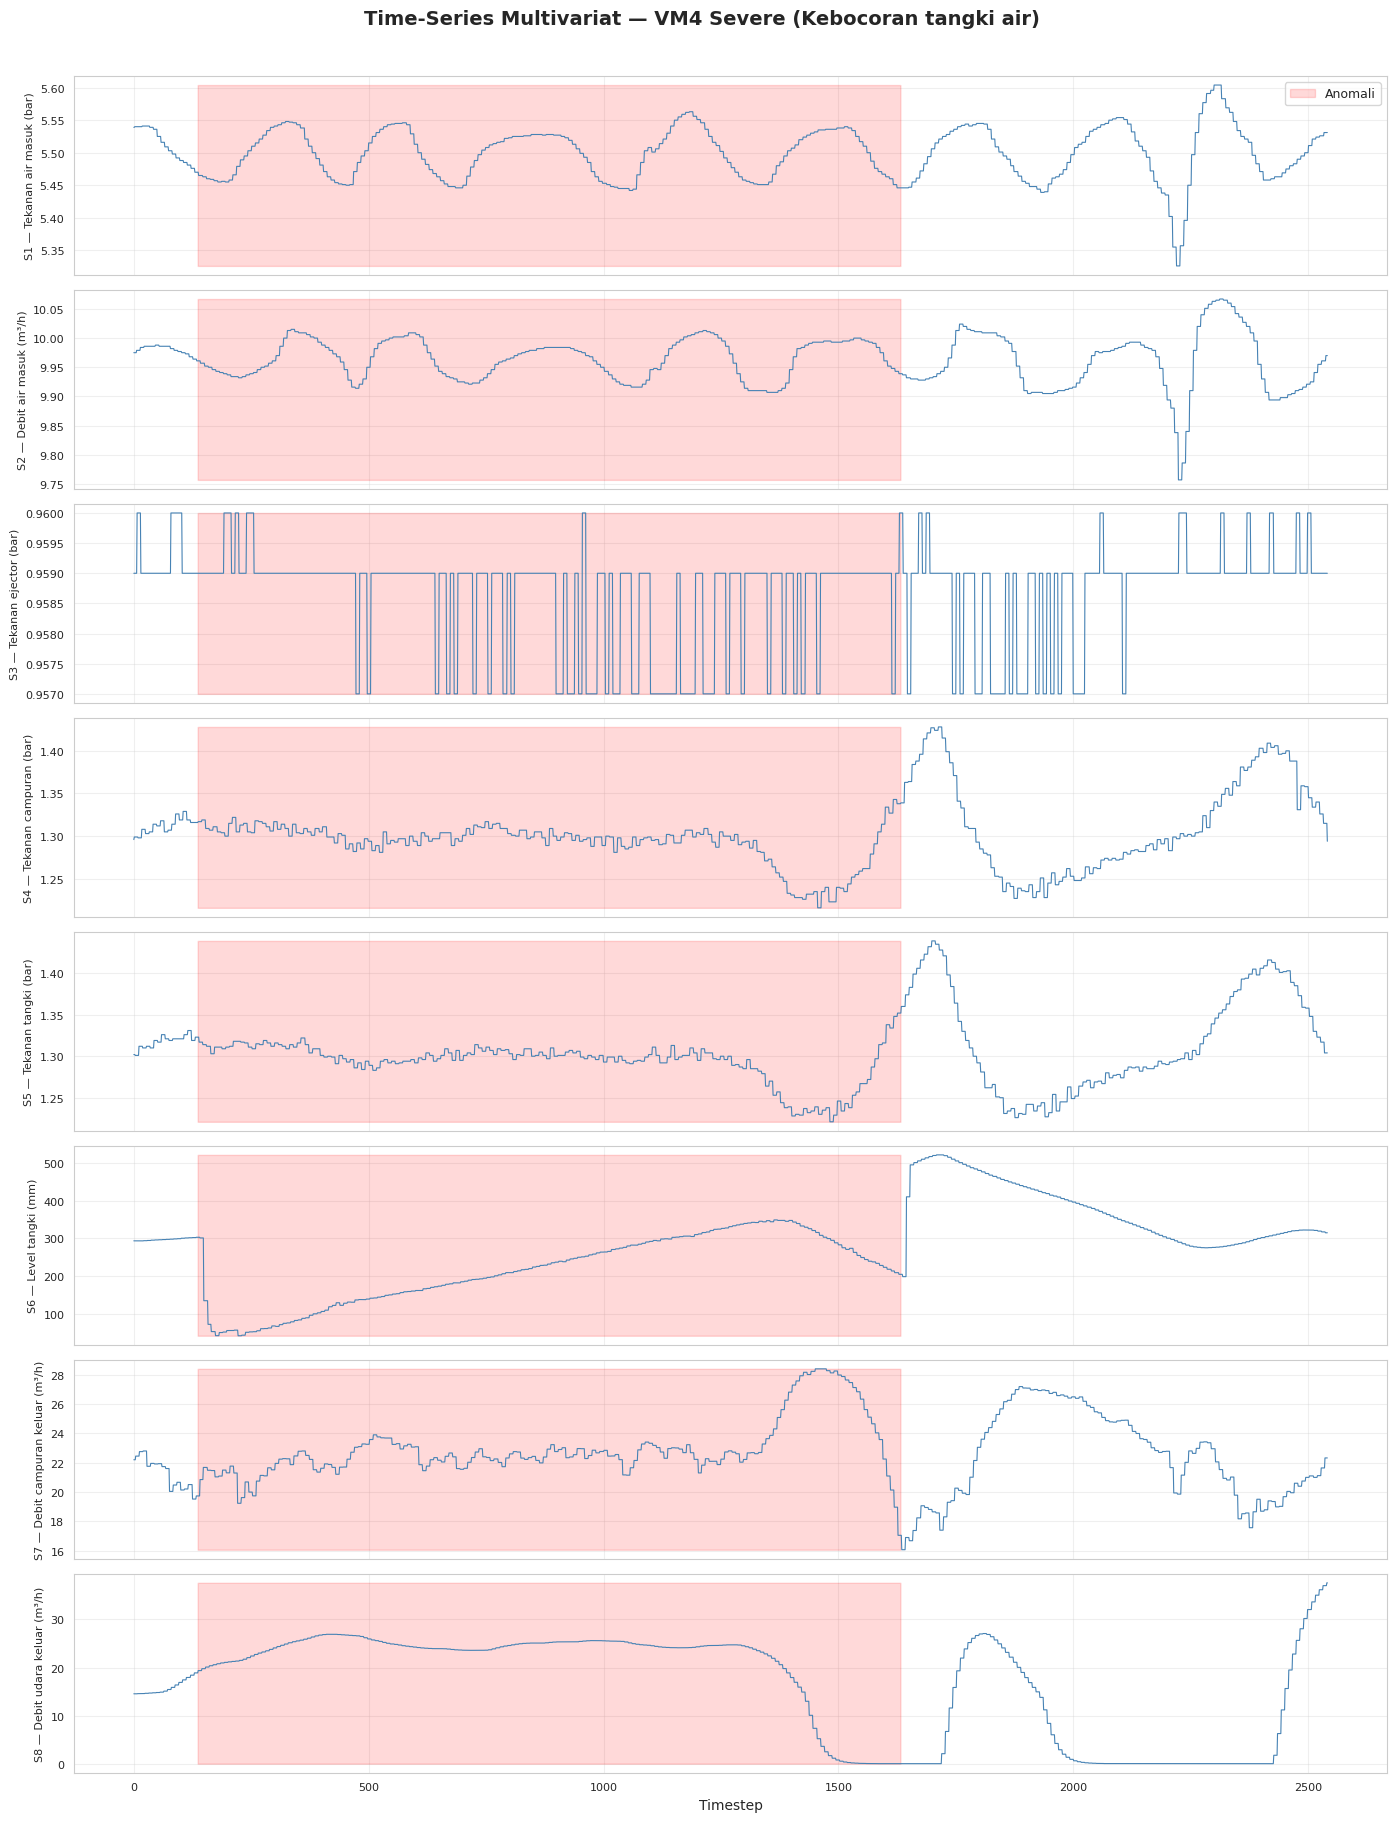

Disimpan: /kaggle/working/eda_final/12_timeseries_VM4_severe.png

[VM5_severe]  N=1,792  Normal=1,460  Anomali=332


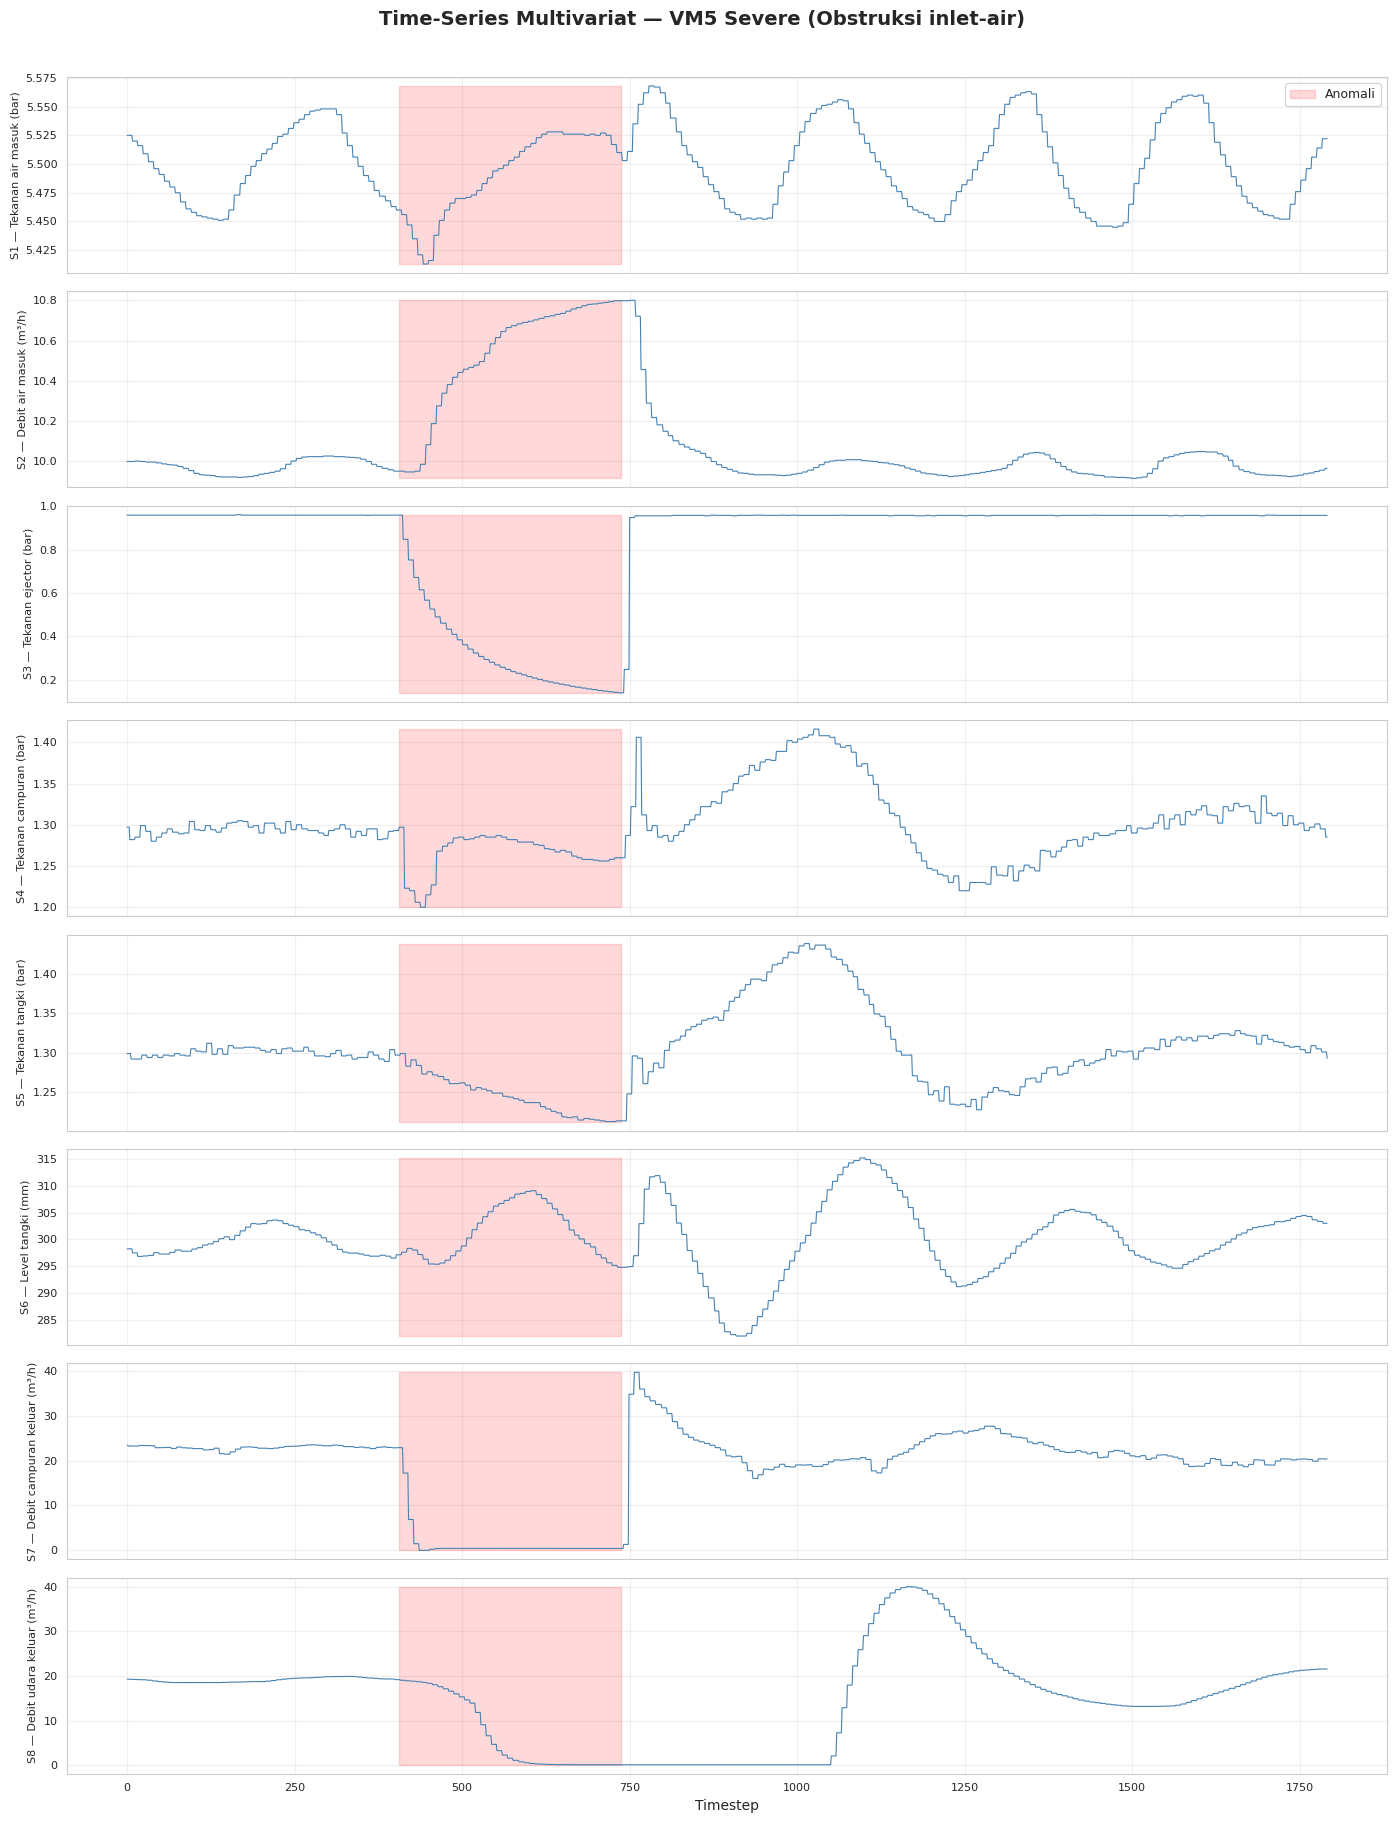

Disimpan: /kaggle/working/eda_final/12_timeseries_VM5_severe.png

[VM6_severe]  N=3,074  Normal=1,862  Anomali=1,212


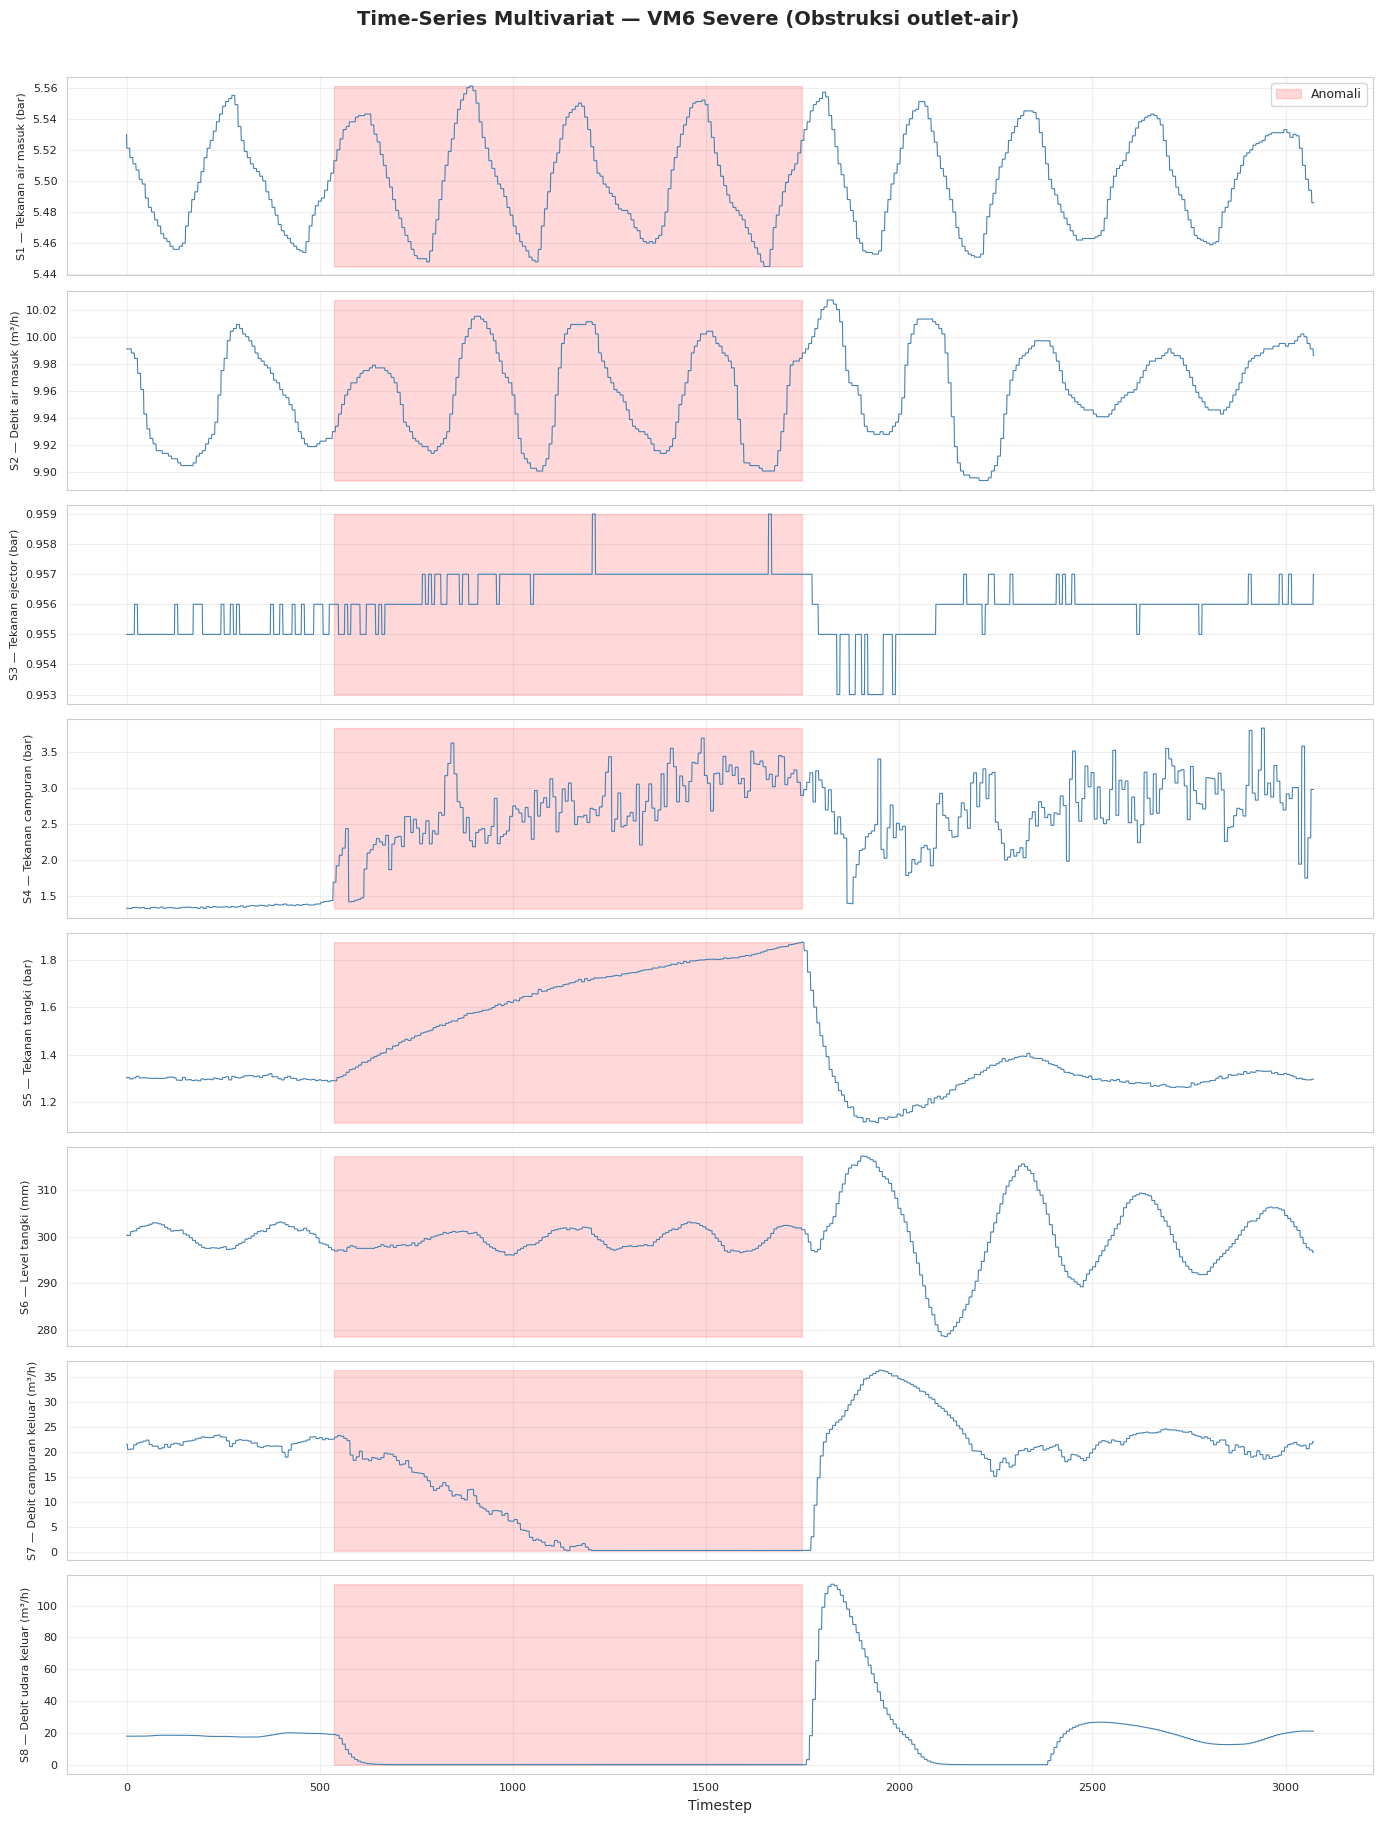

Disimpan: /kaggle/working/eda_final/12_timeseries_VM6_severe.png

[VM7_severe]  N=2,649  Normal=1,439  Anomali=1,210


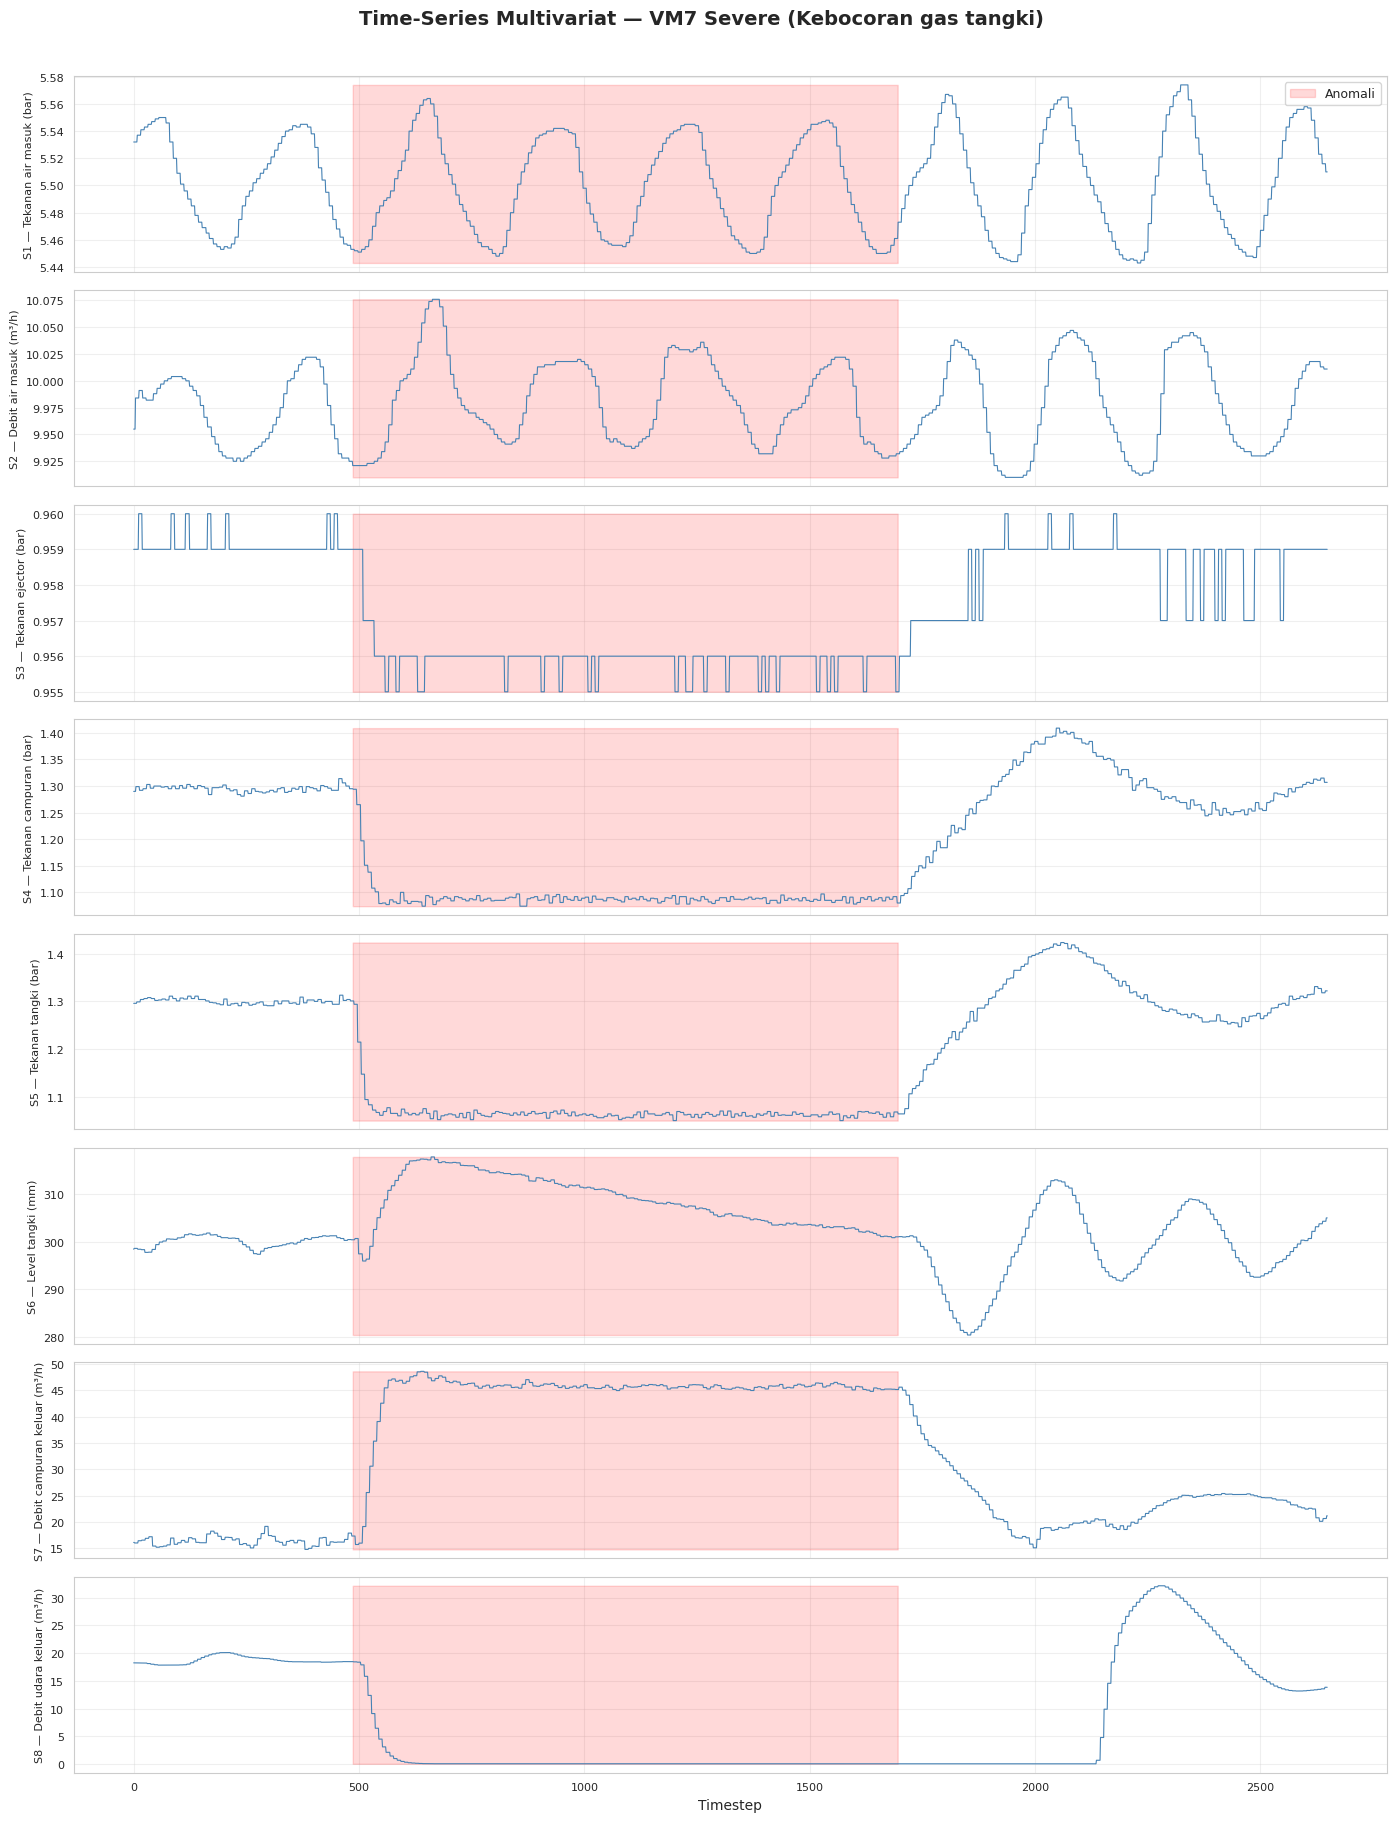

Disimpan: /kaggle/working/eda_final/12_timeseries_VM7_severe.png

Selesai. Pilih file dengan pola paling jelas untuk BAB III.


In [12]:
# ============================================================
# 2.7 — Subplot Time-Series S1–S8 per File TA Severe
# ============================================================
# Visualisasi multivariat: 8 sensor ditampilkan bersamaan terhadap waktu,
# area anomali di-shading merah. Satu figure per file TA (7 total).
# Pilih file terbaik untuk ditampilkan di BAB III (3.1.1).
# ============================================================

SENSOR_LABELS = {
    "S1": "S1 — Tekanan air masuk (bar)",
    "S2": "S2 — Debit air masuk (m³/h)",
    "S3": "S3 — Tekanan ejector (bar)",
    "S4": "S4 — Tekanan campuran (bar)",
    "S5": "S5 — Tekanan tangki (bar)",
    "S6": "S6 — Level tangki (mm)",
    "S7": "S7 — Debit campuran keluar (m³/h)",
    "S8": "S8 — Debit udara keluar (m³/h)",
}

VM_DESCRIPTIONS = {
    "VM1": "Obstruksi inlet-water",
    "VM2": "Obstruksi ejector",
    "VM3": "Obstruksi outlet-water",
    "VM4": "Kebocoran tangki air",
    "VM5": "Obstruksi inlet-air",
    "VM6": "Obstruksi outlet-air",
    "VM7": "Kebocoran gas tangki",
}


def plot_timeseries_multivariate(df, valve_name, output_dir):
    """
    Plot 8 subplot (S1–S8) terhadap waktu untuk satu file TA.
    Area label=1 (anomali) di-shading merah muda.
    """
    fig, axes = plt.subplots(8, 1, figsize=(14, 18), sharex=True)

    desc = VM_DESCRIPTIONS.get(valve_name, "")
    fig.suptitle(
        f"Time-Series Multivariat — {valve_name} Severe ({desc})",
        fontsize=14, fontweight="bold", y=1.01,
    )

    time_axis = np.arange(len(df))  # indeks waktu (timestep)
    labels = df["label"].values

    for i, sensor in enumerate(SENSOR_COLS):
        ax = axes[i]
        values = df[sensor].values

        # Plot sinyal sensor
        ax.plot(time_axis, values, linewidth=0.8, color="steelblue")

        # Shading area anomali
        anomaly_mask = labels == 1
        ax.fill_between(
            time_axis, values.min(), values.max(),
            where=anomaly_mask,
            color="red", alpha=0.15, label="Anomali" if i == 0 else None,
        )

        # Label
        ax.set_ylabel(SENSOR_LABELS.get(sensor, sensor), fontsize=8)
        ax.tick_params(labelsize=8)
        ax.grid(alpha=0.3)

        # Batas Y sedikit diperlebar agar shading terlihat
        ymin, ymax = values.min(), values.max()
        margin = (ymax - ymin) * 0.05 if ymax > ymin else 0.1
        ax.set_ylim(ymin - margin, ymax + margin)

    axes[-1].set_xlabel("Timestep", fontsize=10)
    axes[0].legend(loc="upper right", fontsize=9)

    plt.tight_layout()
    out_path = output_dir / f"12_timeseries_{valve_name}_severe.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Disimpan: {out_path}")


# Jalankan untuk semua 7 file TA severe
print("=" * 70)
print("  2.7 — SUBPLOT TIME-SERIES S1–S8 PER FILE TA SEVERE")
print("=" * 70)

for valve_key, df_ta in ta_dfs.items():
    valve_name = valve_key.replace("_severe", "")  # VM1, VM2, ...
    print(f"\n[{valve_key}]  N={len(df_ta):,}  "
          f"Normal={int((df_ta['label']==0).sum()):,}  "
          f"Anomali={int((df_ta['label']==1).sum()):,}")
    plot_timeseries_multivariate(df_ta, valve_name, OUTPUT_DIR)

print("\nSelesai. Pilih file dengan pola paling jelas untuk BAB III.")

## 2.8 - Heatmap korelasi antar sensor

  2.8 — HEATMAP KORELASI (TA Normal vs TA Anomali)


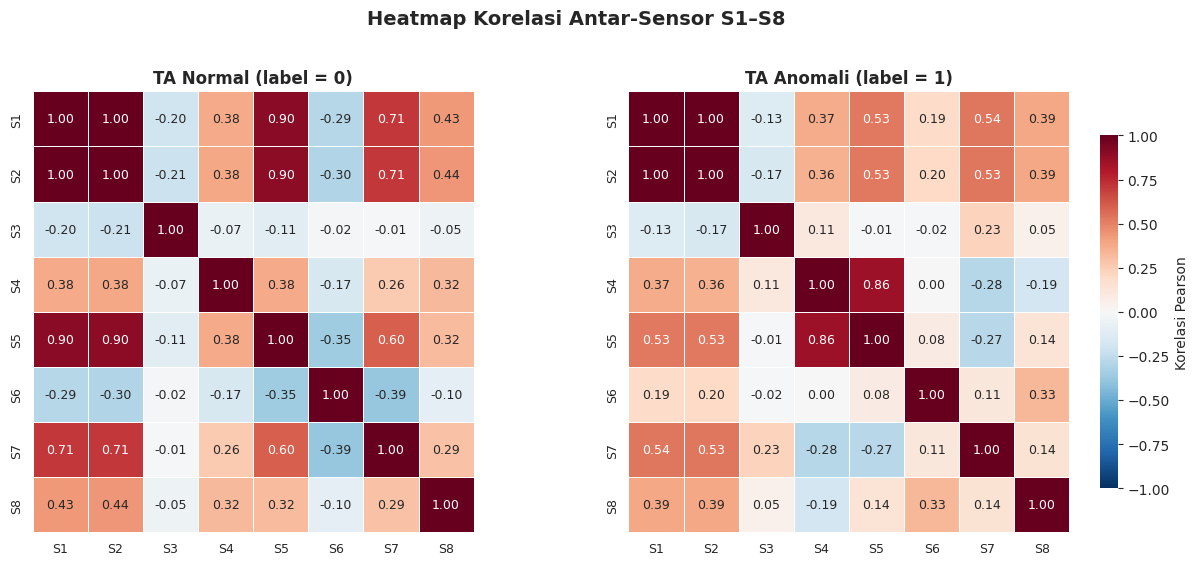


Disimpan: /kaggle/working/eda_final/13_heatmap_korelasi_normal_vs_anomali.png

Perubahan korelasi terbesar (Anomali − Normal):
--------------------------------------------------
Pasangan  r Normal  r Anomali     Δr   |Δr|
   S5–S7    +0.596     -0.275 -0.871 +0.871
   S4–S7    +0.260     -0.282 -0.541 +0.541
   S4–S8    +0.321     -0.185 -0.506 +0.506
   S6–S7    -0.390     +0.113 +0.503 +0.503
   S2–S6    -0.299     +0.196 +0.495 +0.495
   S1–S6    -0.287     +0.194 +0.481 +0.481
   S4–S5    +0.378     +0.859 +0.481 +0.481
   S5–S6    -0.355     +0.083 +0.438 +0.438
   S6–S8    -0.099     +0.332 +0.431 +0.431
   S1–S5    +0.900     +0.529 -0.370 +0.370


In [13]:
# ============================================================
# 2.8 — Heatmap Korelasi Antar-Sensor (TA Normal vs TA Anomali)
# ============================================================
# Dua panel berdampingan: korelasi Pearson antar S1–S8
# pada segmen normal dan segmen anomali dari 7 file TA severe.
# ============================================================

print("=" * 70)
print("  2.8 — HEATMAP KORELASI (TA Normal vs TA Anomali)")
print("=" * 70)

corr_normal  = df_ta_normal[SENSOR_COLS].corr()
corr_anomali = df_ta_anomali[SENSOR_COLS].corr()

# Perbedaan korelasi (untuk referensi cetak, tidak diplot)
corr_diff = corr_anomali - corr_normal

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# Rentang warna simetris agar perbandingan visual adil
vmin, vmax = -1, 1
cmap = "RdBu_r"

sns.heatmap(
    corr_normal, annot=True, fmt=".2f", cmap=cmap,
    vmin=vmin, vmax=vmax, center=0,
    square=True, linewidths=0.5, cbar=False, ax=ax1,
    annot_kws={"size": 9},
)
ax1.set_title("TA Normal (label = 0)", fontsize=12, fontweight="bold")
ax1.tick_params(labelsize=9)

sns.heatmap(
    corr_anomali, annot=True, fmt=".2f", cmap=cmap,
    vmin=vmin, vmax=vmax, center=0,
    square=True, linewidths=0.5, cbar=True, ax=ax2,
    annot_kws={"size": 9},
    cbar_kws={"shrink": 0.8, "label": "Korelasi Pearson"},
)
ax2.set_title("TA Anomali (label = 1)", fontsize=12, fontweight="bold")
ax2.tick_params(labelsize=9)

fig.suptitle(
    "Heatmap Korelasi Antar-Sensor S1–S8",
    fontsize=14, fontweight="bold", y=1.02,
)

plt.tight_layout()
out_path = OUTPUT_DIR / "13_heatmap_korelasi_normal_vs_anomali.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nDisimpan: {out_path}")

# Cetak pasangan dengan perubahan korelasi terbesar
print("\nPerubahan korelasi terbesar (Anomali − Normal):")
print("-" * 50)
pairs = []
for i, s1 in enumerate(SENSOR_COLS):
    for j, s2 in enumerate(SENSOR_COLS):
        if i < j:
            pairs.append({
                "Pasangan": f"{s1}–{s2}",
                "r Normal": corr_normal.loc[s1, s2],
                "r Anomali": corr_anomali.loc[s1, s2],
                "Δr": corr_diff.loc[s1, s2],
                "|Δr|": abs(corr_diff.loc[s1, s2]),
            })
df_pairs = pd.DataFrame(pairs).sort_values("|Δr|", ascending=False)
print(df_pairs.head(10).to_string(index=False, float_format=lambda v: f"{v:+.3f}"))

# 3 - Uji Statistik: Effect Size dan Signifikansi Multivariat

## 3.1 - Cohens'd per Sensor

In [14]:
def compute_cohens_d(group1: pd.Series, group2: pd.Series) -> float:
    """
    Cohen's d untuk dua sampel independen (pooled standard deviation).
    d = (mean2 - mean1) / pooled_std
    Konvensi: |d|<0.2 negligible, 0.2-0.5 small, 0.5-0.8 medium, >0.8 large
    """
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(ddof=1), group2.var(ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (group2.mean() - group1.mean()) / pooled_std


def interpret_cohens_d(d: float) -> str:
    ad = abs(d)
    if ad < 0.2:
        return "negligible"
    elif ad < 0.5:
        return "small"
    elif ad < 0.8:
        return "medium"
    else:
        return "large"


print("=" * 70)
print("  3.1 — COHEN'S D PER SENSOR (TA Normal vs TA Anomali, pooled)")
print("=" * 70)

cohens_d_records = []
for sensor in SENSOR_COLS:
    d = compute_cohens_d(df_ta_normal[sensor], df_ta_anomali[sensor])
    cohens_d_records.append({
        "Sensor": sensor,
        "Unit": SENSOR_UNITS.get(sensor, ""),
        "Mean Normal": df_ta_normal[sensor].mean(),
        "Mean Anomali": df_ta_anomali[sensor].mean(),
        "Cohen's d": d,
        "|d|": abs(d),
        "Interpretasi": interpret_cohens_d(d),
    })

df_cohens_d = pd.DataFrame(cohens_d_records).sort_values("|d|", ascending=False).reset_index(drop=True)

print("\nTabel Cohen's d (diurutkan dari efek terbesar):")
print(df_cohens_d.to_string(index=False, float_format=lambda v: f"{v:.2f}"))

output_path = OUTPUT_DIR / "10_cohens_d_pooled.csv"
df_cohens_d.to_csv(output_path, index=False)
print(f"\nDisimpan: {output_path}")

  3.1 — COHEN'S D PER SENSOR (TA Normal vs TA Anomali, pooled)

Tabel Cohen's d (diurutkan dari efek terbesar):
Sensor Unit  Mean Normal  Mean Anomali  Cohen's d  |d| Interpretasi
    S3  bar         0.96          0.94      -0.26 0.26        small
    S6   mm       326.06        301.85      -0.25 0.25        small
    S4  bar         1.40          1.49       0.15 0.15   negligible
    S5  bar         1.23          1.25       0.12 0.12   negligible
    S8 m³/h        10.76          9.13      -0.12 0.12   negligible
    S1  bar         4.31          4.42       0.05 0.05   negligible
    S7 m³/h        18.35         17.82      -0.04 0.04   negligible
    S2 m³/h         7.74          7.75       0.00 0.00   negligible

Disimpan: /kaggle/working/eda_final/10_cohens_d_pooled.csv


## 3.2 - Hotelling T²

In [15]:
from scipy import stats as scipy_stats

def hotelling_t2_two_sample(X1: np.ndarray, X2: np.ndarray) -> dict:
    """
    Uji Hotelling T² dua sampel untuk perbedaan vektor rata-rata multivariat.
    H0: mean vector kelompok 1 = mean vector kelompok 2.
    T² dikonversi ke distribusi F untuk p-value.
    """
    n1, n2 = X1.shape[0], X2.shape[0]
    p = X1.shape[1]

    mean1, mean2 = X1.mean(axis=0), X2.mean(axis=0)
    S1 = np.cov(X1, rowvar=False, ddof=1)
    S2 = np.cov(X2, rowvar=False, ddof=1)
    S_pooled = ((n1 - 1) * S1 + (n2 - 1) * S2) / (n1 + n2 - 2)

    diff = (mean1 - mean2).reshape(-1, 1)
    S_pooled_inv = np.linalg.inv(S_pooled)
    t2_stat = (n1 * n2 / (n1 + n2)) * (diff.T @ S_pooled_inv @ diff).item()

    df1 = p
    df2 = n1 + n2 - p - 1
    f_stat = ((n1 + n2 - p - 1) / (p * (n1 + n2 - 2))) * t2_stat
    p_value = 1 - scipy_stats.f.cdf(f_stat, df1, df2)

    return {"n1": n1, "n2": n2, "p": p, "T2": t2_stat,
            "F": f_stat, "df1": df1, "df2": df2, "p_value": p_value}


print("=" * 70)
print("  3.2 — HOTELLING T² (TA Normal vs TA Anomali, pooled)")
print("=" * 70)

X_normal = df_ta_normal[SENSOR_COLS].values
X_anomali = df_ta_anomali[SENSOR_COLS].values
result_t2 = hotelling_t2_two_sample(X_normal, X_anomali)

print(f"\nn (TA Normal)   : {result_t2['n1']:,}")
print(f"n (TA Anomali)  : {result_t2['n2']:,}")
print(f"Dimensi (p)     : {result_t2['p']}")
print(f"T² statistic    : {result_t2['T2']:.2f}")
print(f"F statistic     : {result_t2['F']:.2f}")
print(f"df              : ({result_t2['df1']}, {result_t2['df2']})")
print(f"p-value         : {result_t2['p_value']:.6g}")

kesimpulan = ("H0 ditolak (p<0.001)" if result_t2["p_value"] < 0.001
              else "H0 ditolak (p<0.05)" if result_t2["p_value"] < 0.05
              else "H0 tidak ditolak")
print(f"\nKesimpulan: {kesimpulan} — vektor rata-rata kedua kelompok berbeda signifikan"
      if "ditolak" in kesimpulan else f"\nKesimpulan: {kesimpulan}")

print("\nCatatan metodologis:")
print("  Data time-series memiliki autokorelasi antar observasi berurutan,")
print("  melanggar asumsi independensi Hotelling T². P-value cenderung")
print("  terlalu optimis dan dibaca sebagai bukti eksploratif adanya sinyal")
print("  statistik multivariat, bukan uji inferensial formal.")

df_t2_summary = pd.DataFrame([{
    "Kelompok 1": "TA Normal", "Kelompok 2": "TA Anomali",
    "n1": result_t2["n1"], "n2": result_t2["n2"],
    "T2": result_t2["T2"], "F": result_t2["F"],
    "df1": result_t2["df1"], "df2": result_t2["df2"],
    "p_value": result_t2["p_value"],
}])

output_path = OUTPUT_DIR / "11_hotelling_t2_pooled.csv"
df_t2_summary.to_csv(output_path, index=False)
print(f"\nDisimpan: {output_path}")

  3.2 — HOTELLING T² (TA Normal vs TA Anomali, pooled)

n (TA Normal)   : 11,732
n (TA Anomali)  : 7,108
Dimensi (p)     : 8
T² statistic    : 2221.31
F statistic     : 277.56
df              : (8, 18831)
p-value         : 1.11022e-16

Kesimpulan: H0 ditolak (p<0.001) — vektor rata-rata kedua kelompok berbeda signifikan

Catatan metodologis:
  Data time-series memiliki autokorelasi antar observasi berurutan,
  melanggar asumsi independensi Hotelling T². P-value cenderung
  terlalu optimis dan dibaca sebagai bukti eksploratif adanya sinyal
  statistik multivariat, bukan uji inferensial formal.

Disimpan: /kaggle/working/eda_final/11_hotelling_t2_pooled.csv


In [16]:
print("=" * 70)
print("  3.3 — HOTELLING T² (Semua WC Normal vs TA Normal)")
print("=" * 70)

X_wc_all   = df_wc_all[SENSOR_COLS].values
X_ta_normal = df_ta_normal[SENSOR_COLS].values

result_t2_domain = hotelling_t2_two_sample(X_wc_all, X_ta_normal)

print(f"\nn (Semua WC Normal) : {result_t2_domain['n1']:,}")
print(f"n (TA Normal)       : {result_t2_domain['n2']:,}")
print(f"Dimensi (p)         : {result_t2_domain['p']}")
print(f"T² statistic        : {result_t2_domain['T2']:.2f}")
print(f"F statistic         : {result_t2_domain['F']:.2f}")
print(f"df                  : ({result_t2_domain['df1']}, {result_t2_domain['df2']})")
print(f"p-value             : {result_t2_domain['p_value']:.6g}")

kesimpulan = (
    "H0 ditolak (p<0.001)"
    if result_t2_domain["p_value"] < 0.001
    else "H0 ditolak (p<0.05)"
    if result_t2_domain["p_value"] < 0.05
    else "H0 tidak ditolak"
)

print(
    f"\nKesimpulan: {kesimpulan} — vektor rata-rata kedua kelompok berbeda signifikan"
    if "ditolak" in kesimpulan
    else f"\nKesimpulan: {kesimpulan}"
)

print("\nCatatan metodologis:")
print("  Data time-series memiliki autokorelasi antar observasi berurutan,")
print("  melanggar asumsi independensi Hotelling T².")
print("  P-value cenderung terlalu optimis dan dibaca sebagai bukti")
print("  eksploratif adanya domain shift statistik multivariat,")
print("  bukan uji inferensial formal.")

# Simpan hasil
df_t2_domain_summary = pd.DataFrame([{
    "Kelompok 1"  : "Semua WC Normal",
    "Kelompok 2"  : "TA Normal",
    "n1"          : result_t2_domain["n1"],
    "n2"          : result_t2_domain["n2"],
    "T2"          : result_t2_domain["T2"],
    "F"           : result_t2_domain["F"],
    "df1"         : result_t2_domain["df1"],
    "df2"         : result_t2_domain["df2"],
    "p_value"     : result_t2_domain["p_value"],
}])

output_path = OUTPUT_DIR / "12_hotelling_t2_domain_shift.csv"
df_t2_domain_summary.to_csv(output_path, index=False)
print(f"\nDisimpan: {output_path}")

  3.3 — HOTELLING T² (Semua WC Normal vs TA Normal)

n (Semua WC Normal) : 112,195
n (TA Normal)       : 11,732
Dimensi (p)         : 8
T² statistic        : 21767.71
F statistic         : 2720.81
df                  : (8, 123918)
p-value             : 1.11022e-16

Kesimpulan: H0 ditolak (p<0.001) — vektor rata-rata kedua kelompok berbeda signifikan

Catatan metodologis:
  Data time-series memiliki autokorelasi antar observasi berurutan,
  melanggar asumsi independensi Hotelling T².
  P-value cenderung terlalu optimis dan dibaca sebagai bukti
  eksploratif adanya domain shift statistik multivariat,
  bukan uji inferensial formal.

Disimpan: /kaggle/working/eda_final/12_hotelling_t2_domain_shift.csv
